In [ ]:
from google.colab import files
import io
import os
import re
import html
import unicodedata
import zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold

print("Upload either:")
print("  • Train.csv and Test.csv, OR")
print("  • the challenge ZIP containing those files.")
uploaded = files.upload()

Upload either:
  • Train.csv and Test.csv, OR
  • the challenge ZIP containing those files.


Saving gender-based-violence-tweet-classification-challenge.zip to gender-based-violence-tweet-classification-challenge.zip


In [ ]:
# Locate and load Train.csv / Test.csv from uploaded files.
uploaded_names = list(uploaded.keys())

train_name = next((n for n in uploaded_names if "train" in os.path.basename(n).lower()), None)
test_name = next((n for n in uploaded_names if "test" in os.path.basename(n).lower()), None)

if train_name and test_name:
    train = pd.read_csv(io.BytesIO(uploaded[train_name]))
    test = pd.read_csv(io.BytesIO(uploaded[test_name]))
else:
    zip_name = next((n for n in uploaded_names if n.lower().endswith(".zip")), None)
    if zip_name is None:
        raise FileNotFoundError(
            "Please upload Train.csv + Test.csv, or upload the challenge ZIP file."
        )

    with zipfile.ZipFile(io.BytesIO(uploaded[zip_name])) as z:
        members = {os.path.basename(name).lower(): name for name in z.namelist()}
        train_member = next((val for key, val in members.items() if "train.csv" in key), None)
        test_member = next((val for key, val in members.items() if "test.csv" in key), None)
        if not train_member or not test_member:
            raise FileNotFoundError("The ZIP does not contain both Train.csv and Test.csv.")
        with z.open(train_member) as f:
            train = pd.read_csv(f)
        with z.open(test_member) as f:
            test = pd.read_csv(f)

print(f"Train shape: {train.shape}")
print(f"Test shape : {test.shape}")
print("\nTrain columns:", train.columns.tolist())
print("Test columns :", test.columns.tolist())

Train shape: (39650, 3)
Test shape : (15581, 2)

Train columns: ['Tweet_ID', 'tweet', 'type']
Test columns : ['Tweet_ID', 'tweet']


In [ ]:
# Basic validation of the expected schema
required_train_cols = {"Tweet_ID", "tweet", "type"}
required_test_cols = {"Tweet_ID", "tweet"}

missing_train = required_train_cols - set(train.columns)
missing_test = required_test_cols - set(test.columns)

if missing_train:
    raise ValueError(f"Missing training columns: {missing_train}")
if missing_test:
    raise ValueError(f"Missing test columns: {missing_test}")

print("Expected columns are present.")
display(train.head())

Expected columns are present.


,Tweet_ID,tweet,type
0,ID_0022DWKP,Had a dream i got raped last night. By a guy i...,sexual_violence
1,ID_00395QYM,he thought the word raped means sex and told m...,sexual_violence
2,ID_003EOSSF,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,sexual_violence
3,ID_004BBHOD,I was sexually abused for 3 years at age 4 to ...,sexual_violence
4,ID_004F7516,Chessy Prout can do better by telling the trut...,sexual_violence


## 1. Dataset structure and data quality

We first check missing values, duplicate rows, duplicate IDs, and duplicate tweet text. These checks are important because duplicate text can cause information leakage if the same content appears in both training and validation data.

In [ ]:
print("TRAINING DATA INFORMATION")
train.info()

print("\nMISSING VALUES")
print(train.isna().sum())

print("\nDUPLICATES")
print("Duplicate full rows :", train.duplicated().sum())
print("Duplicate Tweet_IDs  :", train["Tweet_ID"].duplicated().sum())
print("Duplicate tweet text:", train["tweet"].duplicated().sum())

TRAINING DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39650 entries, 0 to 39649
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Tweet_ID  39650 non-null  object
 1   tweet     39650 non-null  object
 2   type      39650 non-null  object
dtypes: object(3)
memory usage: 929.4+ KB

MISSING VALUES
Tweet_ID    0
tweet       0
type        0
dtype: int64

DUPLICATES
Duplicate full rows : 0
Duplicate Tweet_IDs  : 0
Duplicate tweet text: 8


In [ ]:
# Basic social-media/text characteristics
tweet_text = train["tweet"].astype(str)

quality_summary = pd.DataFrame({
    "Measure": [
        "Training rows",
        "Test rows",
        "Missing tweets",
        "Missing labels",
        "Duplicate full rows",
        "Duplicate Tweet_IDs",
        "Exact duplicate tweet texts",
        "Tweets with HTML entities",
        "Tweets containing emojis",
        "Tweets containing non-ASCII characters",
    ],
    "Value": [
        len(train),
        len(test),
        train["tweet"].isna().sum(),
        train["type"].isna().sum(),
        train.duplicated().sum(),
        train["Tweet_ID"].duplicated().sum(),
        train["tweet"].duplicated().sum(),
        tweet_text.str.contains(r"&[A-Za-z#0-9]+;", regex=True).sum(),
        tweet_text.str.contains(
            r"[\U0001F300-\U0001FAFF\U00002700-\U000027BF\U00002600-\U000026FF]",
            regex=True
        ).sum(),
        tweet_text.apply(lambda x: any(ord(ch) > 127 for ch in x)).sum(),
    ]
})

display(quality_summary)

,Measure,Value
0,Training rows,39650
1,Test rows,15581
2,Missing tweets,0
3,Missing labels,0
4,Duplicate full rows,0
5,Duplicate Tweet_IDs,0
6,Exact duplicate tweet texts,8
7,Tweets with HTML entities,3299
8,Tweets containing emojis,4433
9,Tweets containing non-ASCII characters,16678


## 2. Class distribution

Because this is a multi-class classification task, the distribution of the target classes is important. A severe imbalance means that accuracy alone can be misleading and that the modelling team should consider class-aware evaluation and/or balancing strategies.

,type,count,percentage
0,sexual_violence,32648,82.34
1,Physical_violence,5946,15.00
2,emotional_violence,651,1.64
3,economic_violence,217,0.55
4,Harmful_Traditional_practice,188,0.47


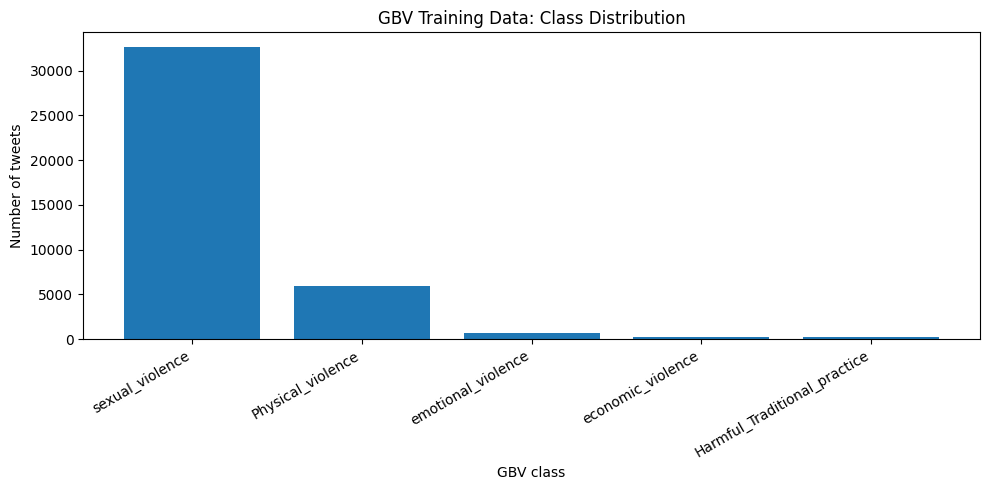

In [ ]:
class_counts = train["type"].value_counts().rename_axis("type").reset_index(name="count")
class_counts["percentage"] = (class_counts["count"] / len(train) * 100).round(2)

display(class_counts)

plt.figure(figsize=(10, 5))
plt.bar(class_counts["type"], class_counts["count"])
plt.title("GBV Training Data: Class Distribution")
plt.xlabel("GBV class")
plt.ylabel("Number of tweets")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

The classes are highly imbalanced: sexual violence is 82.3% of tweets, physical violence 15.0%, and the other three classes together under 3% (emotional 1.64%, economic 0.55%, harmful traditional practices 0.47%). A model that always predicts "sexual_violence" would already reach about 82% accuracy, so accuracy alone is misleading. This is why we use **macro-F1** as our main metric and test **class weights** in the models.

## 3. Tweet/sequence length analysis

Tweet length matters for sequential models because it affects the number of tokens each model must process. We inspect both character count and approximate word count.

In [ ]:
train["char_len"] = train["tweet"].astype(str).str.len()
train["word_len"] = train["tweet"].astype(str).str.split().str.len()

length_stats = train[["char_len", "word_len"]].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

display(length_stats)

class_length_summary = train.groupby("type").agg(
    tweets=("tweet", "size"),
    mean_chars=("char_len", "mean"),
    median_chars=("char_len", "median"),
    mean_words=("word_len", "mean"),
    median_words=("word_len", "median")
).round(2)

display(class_length_summary)

,char_len,word_len
count,39650.00,39650.00
mean,199.40,38.89
std,76.63,15.15
min,10.00,2.00
50%,225.00,43.00
75%,270.00,52.00
90%,279.00,56.00
95%,280.00,58.00
99%,286.00,61.00
max,308.00,68.00


,tweets,mean_chars,median_chars,mean_words,median_words
type,,,,,
Harmful_Traditional_practice,188,191.77,210.5,33.92,35.5
Physical_violence,5946,122.68,102.0,23.30,19.0
economic_violence,217,205.38,232.0,40.53,46.0
emotional_violence,651,202.65,225.0,38.48,42.0
sexual_violence,32648,213.31,241.0,41.75,46.0


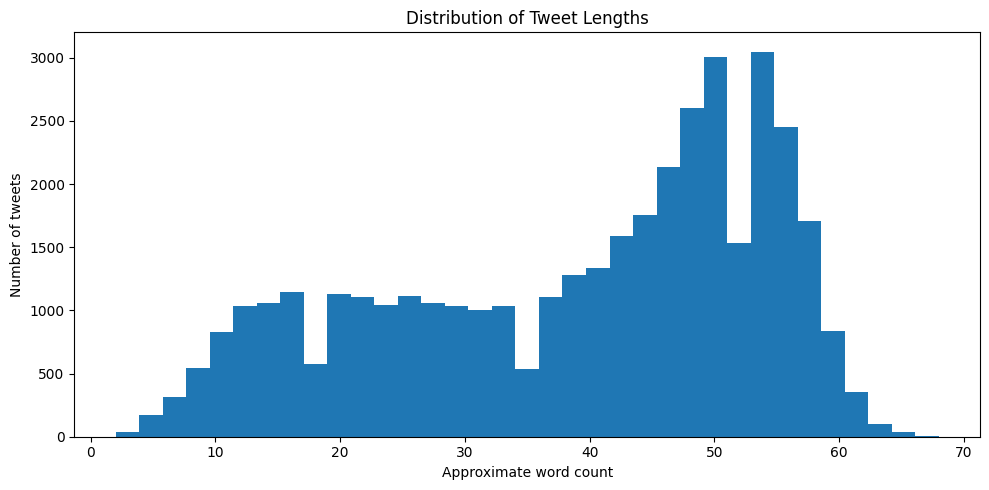

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(train["word_len"], bins=35)
plt.title("Distribution of Tweet Lengths")
plt.xlabel("Approximate word count")
plt.ylabel("Number of tweets")
plt.tight_layout()
plt.show()

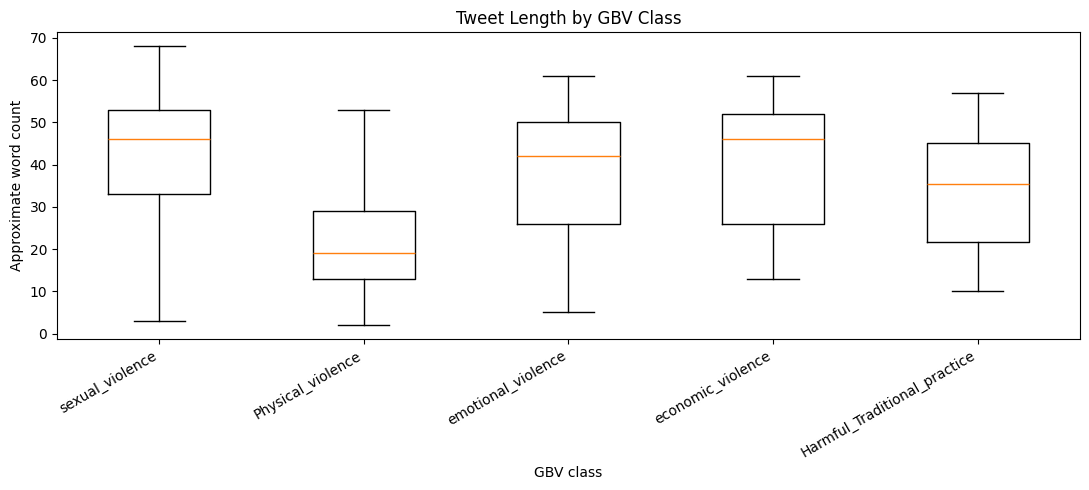

In [ ]:
classes = class_counts["type"].tolist()
box_data = [train.loc[train["type"] == cls, "word_len"] for cls in classes]

plt.figure(figsize=(11, 5))
plt.boxplot(box_data, showfliers=False)
plt.title("Tweet Length by GBV Class")
plt.xlabel("GBV class")
plt.ylabel("Approximate word count")
plt.xticks(range(1, len(classes) + 1), classes, rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

Tweets are short: the median is 43 words, 95% have 58 words or fewer, 99% have 61 or fewer, and the longest has 68. We therefore set the maximum sequence length to **64** for the neural models, which cuts off almost no tweets. Physical-violence tweets are clearly shorter (median 19 words vs 46 for sexual violence), so length itself carries some class information.

## 4. Vocabulary and noisy-text characteristics

Tweets may contain URLs, mentions, punctuation, emojis and spelling variation. We inspect frequent tokens before deciding how much normalization to apply.

In [ ]:
def rough_tokens(text):
    return re.findall(r"\b\w+\b", str(text).lower())

token_counter = Counter()
for text in train["tweet"]:
    token_counter.update(rough_tokens(text))

top_tokens = pd.DataFrame(token_counter.most_common(25), columns=["token", "frequency"])
display(top_tokens)

,token,frequency
0,me,55094
1,he,54965
2,i,54327
3,to,38157
4,and,37866
5,the,36146
6,raped,34299
7,a,34122
8,was,25703
9,my,25347


In [ ]:
# Inspect common URL/mention/hashtag-style patterns
social_features = pd.DataFrame({
    "Feature": [
        "URLs",
        "User mentions",
        "Hashtags",
        "Repeated punctuation",
    ],
    "Tweets containing feature": [
        train["tweet"].astype(str).str.contains(r"https?://\S+|www\.\S+", regex=True).sum(),
        train["tweet"].astype(str).str.contains(r"@\w+", regex=True).sum(),
        train["tweet"].astype(str).str.contains(r"#\w+", regex=True).sum(),
        train["tweet"].astype(str).str.contains(r"[!?]{2,}|\.{2,}", regex=True).sum(),
    ]
})

social_features["Percentage"] = (
    social_features["Tweets containing feature"] / len(train) * 100
).round(2)

display(social_features)

,Feature,Tweets containing feature,Percentage
0,URLs,4,0.01
1,User mentions,0,0.00
2,Hashtags,0,0.00
3,Repeated punctuation,7831,19.75


## 5. Light text normalization

The normalization below intentionally avoids aggressive deletion of linguistic information. It:
- decodes HTML entities,
- applies Unicode normalization,
- replaces URLs with `<URL>`,
- replaces user mentions with `<USER>`,
- normalizes whitespace.

Punctuation, hashtags, emojis and word order are retained for later model-specific tokenization.

In [ ]:
def normalize_tweet(text):
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)

    # Replace URLs
    text = re.sub(r"https?://\S+|www\.\S+", " <URL> ", text)

    # Replace user mentions
    text = re.sub(r"@\w+", " <USER> ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

train["tweet_clean"] = train["tweet"].map(normalize_tweet)
test["tweet_clean"] = test["tweet"].map(normalize_tweet)

display(train[["tweet", "tweet_clean"]].head(10))

,tweet,tweet_clean
0,Had a dream i got raped last night. By a guy i...,Had a dream i got raped last night. By a guy i...
1,he thought the word raped means sex and told m...,he thought the word raped means sex and told m...
2,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...
3,I was sexually abused for 3 years at age 4 to ...,I was sexually abused for 3 years at age 4 to ...
4,Chessy Prout can do better by telling the trut...,Chessy Prout can do better by telling the trut...
5,"Yes men rape women. But women also rape men, y...","Yes men rape women. But women also rape men, y..."
6,"My Husband Beats Me Frequently, Wife Tells Cou...","My Husband Beats Me Frequently, Wife Tells Cou..."
7,Pretty sure he raped a 16yr old girl with 2 fr...,Pretty sure he raped a 16yr old girl with 2 fr...
8,TW sorry to hear that and yeah he recently th...,TW sorry to hear that and yeah he recently thr...
9,"""I understand that... My father was abusive as...","""I understand that... My father was abusive as..."


In [ ]:
# Check what normalization changed and whether it created duplicate text groups.
normalized_duplicate_count = train["tweet_clean"].duplicated().sum()
duplicate_groups_with_conflicting_labels = (
    train.groupby("tweet_clean")["type"].nunique().gt(1).sum()
)
train_test_overlap = len(set(train["tweet_clean"]) & set(test["tweet_clean"]))

normalization_summary = pd.DataFrame({
    "Measure": [
        "Duplicate normalized texts",
        "Normalized-text groups with conflicting labels",
        "Normalized-text overlap between train and test",
    ],
    "Value": [
        normalized_duplicate_count,
        duplicate_groups_with_conflicting_labels,
        train_test_overlap,
    ]
})

display(normalization_summary)

,Measure,Value
0,Duplicate normalized texts,458
1,Normalized-text groups with conflicting labels,2
2,Normalized-text overlap between train and test,9


## 6. Duplicate-aware stratified validation split

A random split can place identical normalized tweets in both training and validation, which can inflate validation performance. We therefore group by normalized tweet text while preserving the target distribution as much as possible.

The modelling team should use these exact exported train/validation files so that all models are compared on the same split.

In [ ]:
groups = train["tweet_clean"].values
y = train["type"].values

sgkf = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(sgkf.split(train, y, groups))

train_model = train.iloc[train_idx].copy()
validation_model = train.iloc[val_idx].copy()

print("Train split:", train_model.shape)
print("Validation split:", validation_model.shape)

overlap = len(
    set(train_model["tweet_clean"]) &
    set(validation_model["tweet_clean"])
)

print("Normalized-text overlap between train and validation:", overlap)

split_summary = pd.concat([
    train_model["type"].value_counts(normalize=True).rename("train_pct") * 100,
    validation_model["type"].value_counts(normalize=True).rename("validation_pct") * 100
], axis=1).round(2)

display(split_summary)

Train split: (35676, 6)
Validation split: (3974, 6)
Normalized-text overlap between train and validation: 0


,train_pct,validation_pct
type,,
sexual_violence,82.32,82.54
Physical_violence,15.03,14.70
emotional_violence,1.63,1.79
economic_violence,0.56,0.45
Harmful_Traditional_practice,0.47,0.53


## 7. Export files for the modelling team

The files below provide a common starting point for all three models. The modelling team can apply model-specific tokenization/feature extraction to the `tweet_clean` column.

In [ ]:
output_dir = "GBV_Person1_Output"
os.makedirs(output_dir, exist_ok=True)

train_model[["Tweet_ID", "tweet", "tweet_clean", "type"]].to_csv(
    f"{output_dir}/train_model.csv", index=False
)

validation_model[["Tweet_ID", "tweet", "tweet_clean", "type"]].to_csv(
    f"{output_dir}/validation_model.csv", index=False
)

test[["Tweet_ID", "tweet", "tweet_clean"]].to_csv(
    f"{output_dir}/test_for_prediction.csv", index=False
)

class_counts.to_csv(
    f"{output_dir}/class_distribution.csv", index=False
)

class_length_summary.to_csv(
    f"{output_dir}/length_summary_by_class.csv"
)

quality_summary.to_csv(
    f"{output_dir}/data_quality_summary.csv", index=False
)

print("Exported files:")
for filename in sorted(os.listdir(output_dir)):
    print(" -", filename)

Exported files:
 - class_distribution.csv
 - data_quality_summary.csv
 - length_summary_by_class.csv
 - test_for_prediction.csv
 - train_model.csv
 - validation_model.csv


# PART 2. MODELLING

## 8. Model 1: TF-IDF + Logistic Regression (baseline)

**What it does:** TF-IDF turns each tweet into numbers, one per word. A word scores high if it appears in this tweet but is rare across all tweets, and low if it appears everywhere (like "the"). Logistic Regression then learns a weight per word for each class and picks the class with the highest total. It ignores word order.

**Why we include it:**
- It tests whether the task is just keyword spotting. If it scores almost as well as the sequential models, word order adds little on this data. Zindi also asks participants to classify "without using keywords" ([Zindi challenge page](https://zindi.africa/competitions/gender-based-violence-tweet-classification-challenge)).
- TF-IDF with Logistic Regression was competitive with deep models on multi-class domestic-violence posts ([Subramani et al., 2019](https://doi.org/10.1109/ACCESS.2019.2908827)).
- Its word weights are readable, which helps error analysis.

Still taking the previously made; `train_model` and `validation_model` split and use the `tweet_clean` column.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# One fixed class order, used by every model so all results line up
CLASS_NAMES = [
    "sexual_violence",
    "Physical_violence",
    "emotional_violence",
    "economic_violence",
    "Harmful_Traditional_practice",
]


X_train_text = train_model["tweet_clean"].astype(str)
X_val_text = validation_model["tweet_clean"].astype(str)
y_train = train_model["type"]
y_val = validation_model["type"]

print("Training tweets  :", len(X_train_text))
print("Validation tweets:", len(X_val_text))

Training tweets  : 35676
Validation tweets: 3974


### 8.1 The score to beat

A "model" that always answers `sexual_violence` needs no learning. Any real model must beat it. It gets high accuracy (about 82%) but a very low macro-F1, because it never finds the four smaller classes. This is why **macro-F1 is our main metric**: it averages the F1 of the five classes, each counted equally.( [Kirk et al.](https://arxiv.org/abs/2303.04222), 2023 used it for imbalanced abuse categories)

In [ ]:
majority_pred = ["sexual_violence"] * len(y_val)

print("Accuracy:", round(accuracy_score(y_val, majority_pred), 4))
print("Macro-F1:", round(f1_score(y_val, majority_pred, labels=CLASS_NAMES, average="macro", zero_division=0), 4))

Accuracy: 0.8254
Macro-F1: 0.1809


### 8.2 One function for every experiment

Every experiment does the same four things:
1. Turn tweets into TF-IDF numbers (vocabulary learned from **training tweets only**).
2. Train Logistic Regression.
3. Predict the validation tweets.
4. Score them and save the result.

We put these in one function, so each experiment is one line and only the settings change.

In [ ]:
results = []   # one row per experiment
trained = {}   # keeps each trained model so we can reuse the best one

def run_experiment(name, ngram_range=(1, 1), class_weight=None, C=1.0):
    # 1. Tweets -> TF-IDF numbers
    tfidf = TfidfVectorizer(lowercase=True, ngram_range=ngram_range, min_df=2, sublinear_tf=True)
    X_train = tfidf.fit_transform(X_train_text)   # learn vocabulary from training tweets
    X_val = tfidf.transform(X_val_text)           # only convert validation tweets

    # 2. Train Logistic Regression
    model = LogisticRegression(C=C, class_weight=class_weight, max_iter=2000)
    model.fit(X_train, y_train)

    # 3. Predict validation tweets
    val_pred = model.predict(X_val)

    # 4. Score and save
    acc = accuracy_score(y_val, val_pred)
    macro_f1 = f1_score(y_val, val_pred, labels=CLASS_NAMES, average="macro", zero_division=0)

    results.append({
        "experiment": name,
        "ngram_range": str(ngram_range),
        "class_weight": str(class_weight),
        "C": C,
        "vocabulary_size": X_train.shape[1],
        "accuracy": round(acc, 4),
        "macro_f1": round(macro_f1, 4),
    })
    trained[name] = (tfidf, model, val_pred)

    print(f"{name}  ->  accuracy = {acc:.4f}  |  macro-F1 = {macro_f1:.4f}")
    return val_pred

### 8.3 Experiment 1: baseline

Simple settings, nothing special:
- single words only (`ngram_range=(1, 1)`)
- words must appear in at least 2 tweets (`min_df=2`)
- default regularization (`C=1.0`)
- **no handling of class imbalance**

This shows what the model does on its own with an 82% majority class.

In [ ]:
pred = run_experiment("Exp 1: baseline")
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

Exp 1: baseline  ->  accuracy = 0.9952  |  macro-F1 = 0.9411
                              precision    recall  f1-score   support

             sexual_violence      0.995     1.000     0.997      3280
           Physical_violence      0.998     0.991     0.995       584
          emotional_violence      1.000     0.944     0.971        71
           economic_violence      1.000     0.833     0.909        18
Harmful_Traditional_practice      1.000     0.714     0.833        21

                    accuracy                          0.995      3974
                   macro avg      0.999     0.896     0.941      3974
                weighted avg      0.995     0.995     0.995      3974



### 8.4 Experiment 2: balanced class weights

**Why:** with 82% of tweets in one class, the model can get a low error by mostly guessing `sexual_violence`, so the small classes get low recall.

**Change:** `class_weight="balanced"` makes a mistake on a rare class cost more than a mistake on a common one. For example, missing one harmful-practice tweet costs roughly as much as missing about 170 sexual-violence tweets.

**Expected:** higher recall on the small classes, possibly slightly lower accuracy.

In [ ]:
pred = run_experiment("Exp 2: balanced weights", class_weight="balanced")
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

Exp 2: balanced weights  ->  accuracy = 0.9962  |  macro-F1 = 0.9750
                              precision    recall  f1-score   support

             sexual_violence      1.000     0.996     0.998      3280
           Physical_violence      0.991     0.998     0.995       584
          emotional_violence      0.922     1.000     0.959        71
           economic_violence      0.857     1.000     0.923        18
Harmful_Traditional_practice      1.000     1.000     1.000        21

                    accuracy                          0.996      3974
                   macro avg      0.954     0.999     0.975      3974
                weighted avg      0.996     0.996     0.996      3974



### 8.5 Experiment 3: words + word pairs

**Why:** single words lose some meaning. "beat" alone is vague, but "beat me" is clear. Word pairs (bigrams) give the model a little bit of word order.

**Change:** `ngram_range=(1, 2)` uses single words **and** pairs of neighbouring words. We keep the class weighting from Experiment 2.

**Expected:** better results if short phrases matter. This is also a first hint for our research question: if a little word order helps here, the sequential models may help more.

In [ ]:
pred = run_experiment("Exp 3: words + word pairs", ngram_range=(1, 2), class_weight="balanced")
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

Exp 3: words + word pairs  ->  accuracy = 0.9952  |  macro-F1 = 0.9767
                              precision    recall  f1-score   support

             sexual_violence      0.999     0.995     0.997      3280
           Physical_violence      0.988     0.997     0.992       584
          emotional_violence      0.899     1.000     0.947        71
           economic_violence      0.900     1.000     0.947        18
Harmful_Traditional_practice      1.000     1.000     1.000        21

                    accuracy                          0.995      3974
                   macro avg      0.957     0.998     0.977      3974
                weighted avg      0.995     0.995     0.995      3974



### 8.6 Compare all experiments

One table with every experiment. We choose the best model by **validation macro-F1**, not accuracy.

,experiment,ngram_range,class_weight,C,vocabulary_size,accuracy,macro_f1
0,Exp 1: baseline,"(1, 1)",None,1.0,17055,0.9952,0.9411
1,Exp 2: balanced weights,"(1, 1)",balanced,1.0,17055,0.9962,0.9750
2,Exp 3: words + word pairs,"(1, 2)",balanced,1.0,113365,0.9952,0.9767


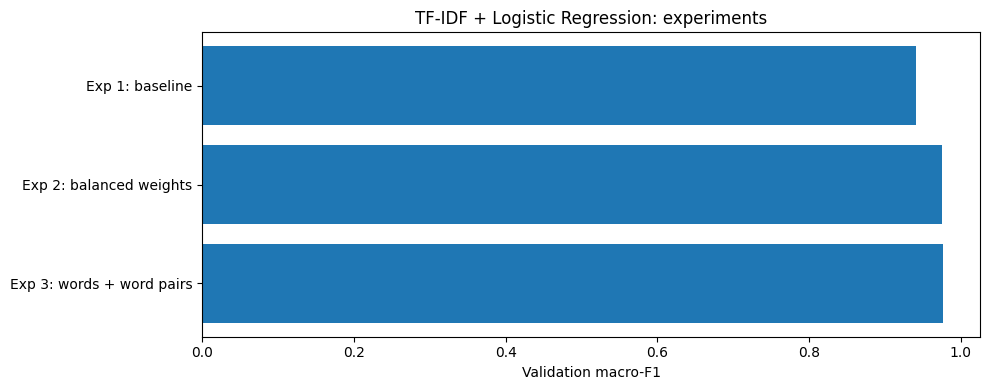

Best experiment: Exp 3: words + word pairs


In [ ]:
results_df = pd.DataFrame(results)
display(results_df)

plt.figure(figsize=(10, 4))
plt.barh(results_df["experiment"], results_df["macro_f1"])
plt.xlabel("Validation macro-F1")
plt.title("TF-IDF + Logistic Regression: experiments")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

best_name = results_df.loc[results_df["macro_f1"].idxmax(), "experiment"]
print("Best experiment:", best_name)

### 8.7 The best model in detail

The classification report shows precision, recall and F1 for each class. In the confusion matrix, rows are the true class, columns are the predicted class, and the numbers are counts. Darker means a higher share of that row. Everything off the diagonal is a mistake.

                              precision    recall  f1-score   support

             sexual_violence      0.999     0.995     0.997      3280
           Physical_violence      0.988     0.997     0.992       584
          emotional_violence      0.899     1.000     0.947        71
           economic_violence      0.900     1.000     0.947        18
Harmful_Traditional_practice      1.000     1.000     1.000        21

                    accuracy                          0.995      3974
                   macro avg      0.957     0.998     0.977      3974
                weighted avg      0.995     0.995     0.995      3974



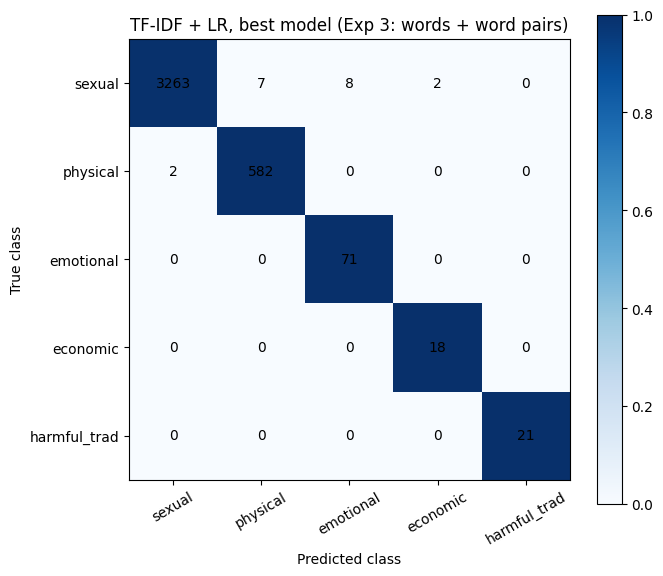

In [ ]:
best_tfidf, best_model, best_pred = trained[best_name]

print(classification_report(y_val, best_pred, labels=CLASS_NAMES, digits=3, zero_division=0))

cm = confusion_matrix(y_val, best_pred, labels=CLASS_NAMES)
short_names = ["sexual", "physical", "emotional", "economic", "harmful_trad"]

plt.figure(figsize=(7, 6))
plt.imshow(cm / cm.sum(axis=1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xticks(range(5), short_names, rotation=30)
plt.yticks(range(5), short_names)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title(f"TF-IDF + LR, best model ({best_name})")
plt.colorbar()
plt.tight_layout()
plt.show()

### 8.8 Which words decide each class?

Logistic Regression gives every word a weight for each class. The 10 highest-weight words are the ones that most strongly push a tweet into that class. If each class is decided by a few obvious words, that supports the idea that this task is largely keyword-driven.

In [ ]:
words = best_tfidf.get_feature_names_out()

top_words = {}
for i, class_name in enumerate(best_model.classes_):
    top_idx = best_model.coef_[i].argsort()[::-1][:10]   # 10 highest weights
    top_words[class_name] = words[top_idx]

display(pd.DataFrame(top_words)[CLASS_NAMES])

,sexual_violence,Physical_violence,emotional_violence,economic_violence,Harmful_Traditional_practice
0,raped,beats,public,fired,forced
1,he,husband,humiliated,job,child marriage
2,raped me,my husband,insulted,woman,marriage
3,he raped,beats me,in public,because,fgm
4,was raped,my,in,was fired,undergo
5,rape,husband beats,insulted me,fired from,mutilation
6,raped and,he beats,the public,job because,genital mutilation
7,me,beats the,humiliated me,was,female genital
8,raped by,wife,verbally,my job,genital
9,raped her,her husband,he insulted,got fired,child


### 8.9 Save results for the final comparison

We save the experiment table and every validation prediction (Tweet ID, tweet, true label, predicted label, and the probability for each class) for the comparison and error analysis purpose. We also start one shared table, `all_model_scores`, that each model adds its best score to. TF-IDF + Logistic Regression gives the same result every run, so its std is 0.

In [ ]:
os.makedirs("results", exist_ok=True)
results_df.to_csv("results/tfidf_lr_experiments.csv", index=False)

# Save every validation prediction (used for comparison and error analysis)
def save_predictions(model_label, pred_labels, probs, filename):
    df = pd.DataFrame({
        "Tweet_ID": validation_model["Tweet_ID"].values,
        "tweet": validation_model["tweet_clean"].values,
        "true_label": y_val.values,
        "predicted_label": pred_labels,
    })
    for i, name in enumerate(CLASS_NAMES):
        df[f"prob_{name}"] = probs[:, i].round(4)   # one probability column per class
    df.to_csv(f"results/{filename}", index=False)
    print(f"Saved results/{filename} ({len(df)} rows, {(df.true_label != df.predicted_label).sum()} wrong)")

# scikit-learn orders classes alphabetically, so reorder the probabilities to CLASS_NAMES
tfidf_probs = best_model.predict_proba(best_tfidf.transform(X_val_text))
order = [list(best_model.classes_).index(name) for name in CLASS_NAMES]
save_predictions("TF-IDF + LR", best_pred, tfidf_probs[:, order], "val_predictions_tfidf_lr.csv")

# TF-IDF + LR gives the same result every run, so its std is 0
all_model_scores = []
all_model_scores.append({
    "model": "TF-IDF + Logistic Regression",
    "best_experiment": best_name,
    "accuracy": round(accuracy_score(y_val, best_pred), 4),
    "macro_f1": round(f1_score(y_val, best_pred, labels=CLASS_NAMES, average="macro", zero_division=0), 4),
    "macro_f1_std": 0.0,
})
display(pd.DataFrame(all_model_scores))

Saved results/val_predictions_tfidf_lr.csv (3974 rows, 19 wrong)


,model,best_experiment,accuracy,macro_f1,macro_f1_std
0,TF-IDF + Logistic Regression,Exp 3: words + word pairs,0.9952,0.9767,0.0


### 8.10 What we learned from TF-IDF + Logistic Regression

- **Class weights (Exp 1 vs Exp 2):** without weights, recall on the small classes was low (emotional 0.944, economic 0.833, harmful practices 0.714). With balanced weights, all three reached 1.000 and macro-F1 rose from 0.941 to 0.975. Accuracy barely moved (0.995 to 0.996), which shows why accuracy alone hides problems on small classes. The cost: precision on the small classes dropped slightly (for example, economic 0.857), because the model now over-predicts them a little.
- **Word pairs (Exp 2 vs Exp 3):** macro-F1 moved from 0.975 to 0.977, about one tweet. We treat this as a tie: adding a little local word order did not clearly help.
- **Top words:** each class is decided by a few obvious words (raped; beats, husband; humiliated, insulted; fired, job; fgm, child marriage). This suggests the task is largely keyword-driven.
- **Best version:** Exp 3, macro-F1 0.977, 19 wrong out of 3,974 validation tweets.

## 9. Model 2: Bidirectional LSTM (BiLSTM)

**What it does:** it reads the tweet word by word, in order, keeping a memory of what it has read. Gates decide what to keep and what to forget. "Bidirectional" means two LSTMs: one reads left to right, the other right to left, and their memories are joined. So every word is understood with context from both sides.

**Why we include it:**
- **It is a sequential model.** Unlike TF-IDF, it uses word order. "He raped me" and "he thought the word raped means sex" (a real tweet in our data) share words but mean different things.
- **Research supports it.** Gated recurrent models (BiLSTM, GRU) were among the best on multi-class domestic-violence posts ([Subramani et al., 2019](https://doi.org/10.1109/ACCESS.2019.2908827)), and LSTM beat CNN on this same GBV dataset ([Kurniawan et al., 2025](https://doi.org/10.47738/jads.v6i3.761)).
- **It answers our research question.** TF-IDF reached a macro-F1 of about 0.977 using only which words appear. If the BiLSTM clearly beats that, word order helps. If not, the task is mostly keyword-driven.

**What TF-IDF taught us before starting:** balanced class weights clearly helped (macro-F1 0.941 to 0.975), so we test them here too.

In [ ]:
# Load PyTorch BEFORE TensorFlow: loading it after TensorFlow can crash the Colab kernel.
# PyTorch is used for DistilBERT in Section 12.
import torch
import transformers

import tensorflow as tf

# Let TensorFlow take GPU memory only as needed, so PyTorch (DistilBERT, Section 12) can share the GPU
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass   # GPU already in use (cell re-run); memory growth must be set before the first GPU operation
import keras
from keras import layers
from sklearn.utils.class_weight import compute_class_weight

label_to_id = {name: i for i, name in enumerate(CLASS_NAMES)}
y_train_ids = y_train.map(label_to_id).to_numpy()
y_val_ids = y_val.map(label_to_id).to_numpy()

print("TensorFlow version:", tf.__version__)
print("GPU available     :", len(tf.config.list_physical_devices("GPU")) > 0)
print("Example labels    :", list(y_train[:3]), "->", list(y_train_ids[:3]))

TensorFlow version: 2.20.0
GPU available     : True
Example labels    : ['sexual_violence', 'sexual_violence', 'sexual_violence'] -> [np.int64(0), np.int64(0), np.int64(0)]


### 9.1 Turn tweets into sequences of numbers

The BiLSTM reads word IDs in order: `"he beat me"` becomes something like `[12, 845, 3]`. Every tweet must have the same length:

- **`MAX_LEN = 64`:** The analysis showed 99% of tweets have 61 words or fewer (longest: 68). Shorter tweets are padded with 0s at the end; the rare longer ones are cut.
- **`VOCAB_SIZE = 20000`:** TF-IDF found 17,055 words that appear in at least 2 tweets, so 20,000 keeps all of them. Any other word becomes the "unknown" ID (1).

The vocabulary is learned from **training tweets only**.

In [ ]:
MAX_LEN = 64
VOCAB_SIZE = 20000

vectorizer = layers.TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN)
vectorizer.adapt(X_train_text.to_numpy())   # learn vocabulary from training tweets only

X_train_seq = vectorizer(X_train_text.to_numpy()).numpy()
X_val_seq = vectorizer(X_val_text.to_numpy()).numpy()

print("Training shape  :", X_train_seq.shape, "(tweets, words)")
print("Validation shape:", X_val_seq.shape)

# Show one tweet as numbers and back to words
vocab = vectorizer.get_vocabulary()
print("\nFirst tweet as numbers:", X_train_seq[0][:12])
print("Back to words         :", [str(vocab[i]) for i in X_train_seq[0][:12]])

Training shape  : (35676, 64) (tweets, words)
Validation shape: (3974, 64)

First tweet as numbers: [ 44   8 987   4  64   9 242 199  38   8  86   4]
Back to words         : ['had', 'a', 'dream', 'i', 'got', 'raped', 'last', 'night', 'by', 'a', 'guy', 'i']


### 9.2 Class weights

Same idea as `class_weight="balanced"` in TF-IDF: a mistake on a rare class costs more during training. Keras needs the weights as a dictionary, so we compute them with the same formula scikit-learn uses:

> weight = total tweets / (number of classes × tweets in that class)

In [ ]:
weights = compute_class_weight(class_weight="balanced", classes=np.arange(len(CLASS_NAMES)), y=y_train_ids)
class_weights = dict(enumerate(weights))

for name, w in zip(CLASS_NAMES, weights):
    print(f"{name:30s} weight = {w:.2f}")

sexual_violence                weight = 0.24
Physical_violence              weight = 1.33
emotional_violence             weight = 12.30
economic_violence              weight = 35.86
Harmful_Traditional_practice   weight = 42.73


### 9.3 Build the model

In [ ]:
def build_model(bidirectional=True):
    model = keras.Sequential([
        keras.Input(shape=(MAX_LEN,)),
        layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128, mask_zero=True),
        layers.Bidirectional(layers.LSTM(64)) if bidirectional else layers.LSTM(64),
        layers.Dropout(0.3),
        layers.Dense(len(CLASS_NAMES), activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

build_model(bidirectional=True).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 64, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,461 (10.15 MB)

 Trainable params: 2,659,461 (10.15 MB)

 Non-trainable params: 0 (0.00 B)

### 9.4 One function for every experiment

Each experiment builds a fresh model, trains it, predicts the validation tweets, and saves the scores.

- **3 seeds per experiment (42, 7, 123).** A neural network starts from random weights set by the seed, so its score moves a little from run to run. Our models differ by only 1 to 2 tweets on the small classes, so one run is not enough to say which is better. We train each experiment 3 times and report the **average** macro-F1 and its spread (std, min, max). Learning curves and confusion matrices show the seed-42 run.
- **Early stopping:** training stops when validation loss hasn't improved for 2 epochs, and the best epoch's weights are kept.
- **Up to 10 epochs, 64 tweets per batch.**

In [ ]:
SEEDS = [42, 7, 123]   # each neural experiment is trained once per seed

rnn_results = []   # one row per experiment (averaged over seeds)
rnn_trained = {}   # keeps the seed-42 model, history and predictions of each experiment

def run_rnn_experiment(name, bidirectional=True, use_class_weights=False):
    accs, f1s = [], []

    for seed in SEEDS:
        keras.utils.set_random_seed(seed)   # different random starting point each run
        model = build_model(bidirectional)
        early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

        history = model.fit(
            X_train_seq, y_train_ids,
            validation_data=(X_val_seq, y_val_ids),
            epochs=10,
            batch_size=64,
            class_weight=class_weights if use_class_weights else None,
            callbacks=[early_stop],
            verbose=0,
        )

        # Highest probability = predicted class, then turn IDs back into class names
        val_pred = [CLASS_NAMES[i] for i in model.predict(X_val_seq, verbose=0).argmax(axis=1)]
        accs.append(accuracy_score(y_val, val_pred))
        f1s.append(f1_score(y_val, val_pred, labels=CLASS_NAMES, average="macro", zero_division=0))
        print(f"{name} | seed {seed:3d} | epochs {len(history.history['loss'])} | macro-F1 = {f1s[-1]:.4f}")

        if seed == SEEDS[0]:   # keep the seed-42 run for curves, confusion matrix and predictions
            rnn_trained[name] = (model, history, val_pred)

    rnn_results.append({
        "experiment": name,
        "direction": "both (BiLSTM)" if bidirectional else "one (LSTM)",
        "class_weights": use_class_weights,
        "accuracy": round(np.mean(accs), 4),
        "macro_f1": round(np.mean(f1s), 4),        # average over the 3 seeds
        "macro_f1_std": round(np.std(f1s), 4),
        "macro_f1_min": round(min(f1s), 4),
        "macro_f1_max": round(max(f1s), 4),
    })
    print(f"\n{name}  ->  average macro-F1 = {np.mean(f1s):.4f} (std {np.std(f1s):.4f})")
    return rnn_trained[name][2]

### 9.5 Experiment 1: BiLSTM baseline

No class weights. This shows what the BiLSTM does on its own, and it matches TF-IDF Experiment 1 so the two can be compared fairly.

In [ ]:
pred = run_rnn_experiment("Exp 1: BiLSTM baseline")
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

Exp 1: BiLSTM baseline | seed  42 | epochs 6 | macro-F1 = 0.9899
Exp 1: BiLSTM baseline | seed   7 | epochs 8 | macro-F1 = 0.9918
Exp 1: BiLSTM baseline | seed 123 | epochs 5 | macro-F1 = 0.9898

Exp 1: BiLSTM baseline  ->  average macro-F1 = 0.9905 (std 0.0009)
                              precision    recall  f1-score   support

             sexual_violence      0.999     1.000     1.000      3280
           Physical_violence      1.000     1.000     1.000       584
          emotional_violence      1.000     1.000     1.000        71
           economic_violence      1.000     1.000     1.000        18
Harmful_Traditional_practice      1.000     0.905     0.950        21

                    accuracy                          0.999      3974
                   macro avg      1.000     0.981     0.990      3974
                weighted avg      0.999     0.999     0.999      3974



### 9.6 Experiment 2: BiLSTM + class weights

**Why:** class weights raised TF-IDF's macro-F1 from 0.941 to 0.975. We test whether the BiLSTM gains the same way on the small classes.

In [ ]:
pred = run_rnn_experiment("Exp 2: BiLSTM + class weights", use_class_weights=True)
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

Exp 2: BiLSTM + class weights | seed  42 | epochs 3 | macro-F1 = 0.8897
Exp 2: BiLSTM + class weights | seed   7 | epochs 10 | macro-F1 = 0.9998
Exp 2: BiLSTM + class weights | seed 123 | epochs 7 | macro-F1 = 0.9906

Exp 2: BiLSTM + class weights  ->  average macro-F1 = 0.9601 (std 0.0499)
                              precision    recall  f1-score   support

             sexual_violence      0.999     0.982     0.991      3280
           Physical_violence      0.992     1.000     0.996       584
          emotional_violence      0.633     0.972     0.767        71
           economic_violence      0.643     1.000     0.783        18
Harmful_Traditional_practice      0.840     1.000     0.913        21

                    accuracy                          0.985      3974
                   macro avg      0.821     0.991     0.890      3974
                weighted avg      0.989     0.985     0.986      3974



### 9.7 Experiment 3: one direction only (plain LSTM)

**Why:** our tweets are short (99% have 61 words or fewer). Reading in both directions may not add much. Here we keep everything the same but read in one direction only.

- **If the BiLSTM clearly wins:** context from both sides helps.
- **If they tie:** for short tweets, one direction is enough.

Same settings as Experiment 1 (no class weights), so the only difference is the direction.

In [ ]:
# Same settings as the best BiLSTM (no class weights), only the reading direction changes
pred = run_rnn_experiment("Exp 3: LSTM one direction", bidirectional=False)
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

Exp 3: LSTM one direction | seed  42 | epochs 7 | macro-F1 = 0.9944
Exp 3: LSTM one direction | seed   7 | epochs 5 | macro-F1 = 0.9825
Exp 3: LSTM one direction | seed 123 | epochs 6 | macro-F1 = 0.9900

Exp 3: LSTM one direction  ->  average macro-F1 = 0.9889 (std 0.0049)
                              precision    recall  f1-score   support

             sexual_violence      1.000     0.999     1.000      3280
           Physical_violence      0.998     1.000     0.999       584
          emotional_violence      1.000     1.000     1.000        71
           economic_violence      0.947     1.000     0.973        18
Harmful_Traditional_practice      1.000     1.000     1.000        21

                    accuracy                          0.999      3974
                   macro avg      0.989     1.000     0.994      3974
                weighted avg      1.000     0.999     1.000      3974



### 9.8 Compare the three experiments

We pick the best experiment by **average validation macro-F1 over the 3 seeds**. When two experiments' min to max ranges overlap, the difference may be due to the random seed rather than the setting.

,experiment,direction,class_weights,accuracy,macro_f1,macro_f1_std,macro_f1_min,macro_f1_max
0,Exp 1: BiLSTM baseline,both (BiLSTM),False,0.9991,0.9905,0.0009,0.9898,0.9918
1,Exp 2: BiLSTM + class weights,both (BiLSTM),True,0.9943,0.9601,0.0499,0.8897,0.9998
2,Exp 3: LSTM one direction,one (LSTM),False,0.9989,0.9889,0.0049,0.9825,0.9944


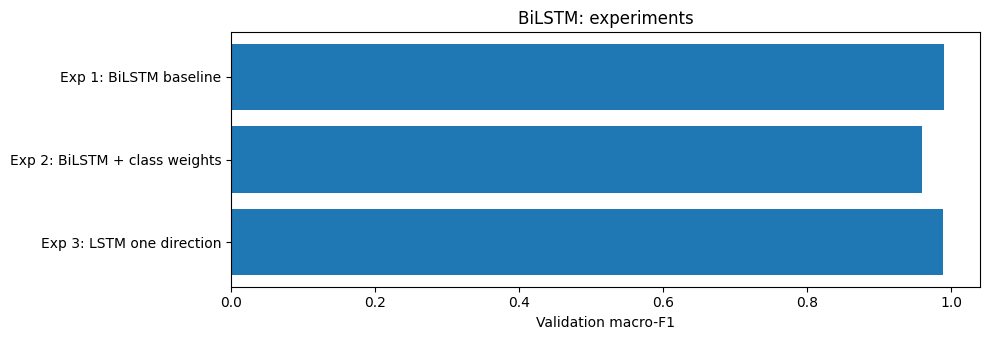

Best experiment: Exp 1: BiLSTM baseline


In [ ]:
rnn_results_df = pd.DataFrame(rnn_results)
display(rnn_results_df)

plt.figure(figsize=(10, 3.5))
plt.barh(rnn_results_df["experiment"], rnn_results_df["macro_f1"])
plt.xlabel("Validation macro-F1")
plt.title("BiLSTM: experiments")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

best_rnn_name = rnn_results_df.loc[rnn_results_df["macro_f1"].idxmax(), "experiment"]
print("Best experiment:", best_rnn_name)

### 9.9 Learning curves of the best experiment

They show how training went, epoch by epoch:
- **Both curves improve:** the model is still learning.
- **Training loss keeps falling while validation loss rises:** overfitting. Early stopping kept the weights from before this point.

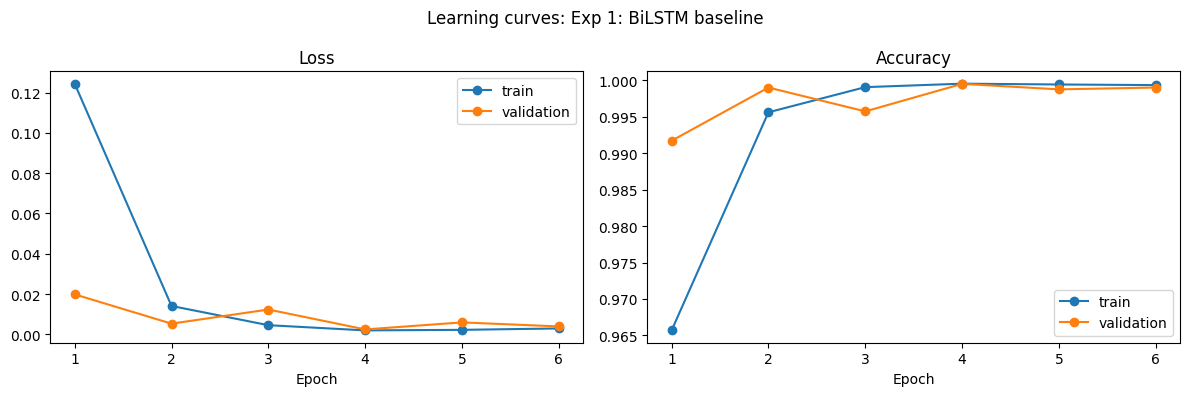

In [ ]:
best_rnn_model, best_history, best_rnn_pred = rnn_trained[best_rnn_name]
hist = pd.DataFrame(best_history.history)
epochs = range(1, len(hist) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, hist["loss"], marker="o", label="train")
axes[0].plot(epochs, hist["val_loss"], marker="o", label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, hist["accuracy"], marker="o", label="train")
axes[1].plot(epochs, hist["val_accuracy"], marker="o", label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle(f"Learning curves: {best_rnn_name}")
plt.tight_layout()
plt.show()

### 9.10 The best BiLSTM in detail

                              precision    recall  f1-score   support

             sexual_violence      0.999     1.000     1.000      3280
           Physical_violence      1.000     1.000     1.000       584
          emotional_violence      1.000     1.000     1.000        71
           economic_violence      1.000     1.000     1.000        18
Harmful_Traditional_practice      1.000     0.905     0.950        21

                    accuracy                          0.999      3974
                   macro avg      1.000     0.981     0.990      3974
                weighted avg      0.999     0.999     0.999      3974



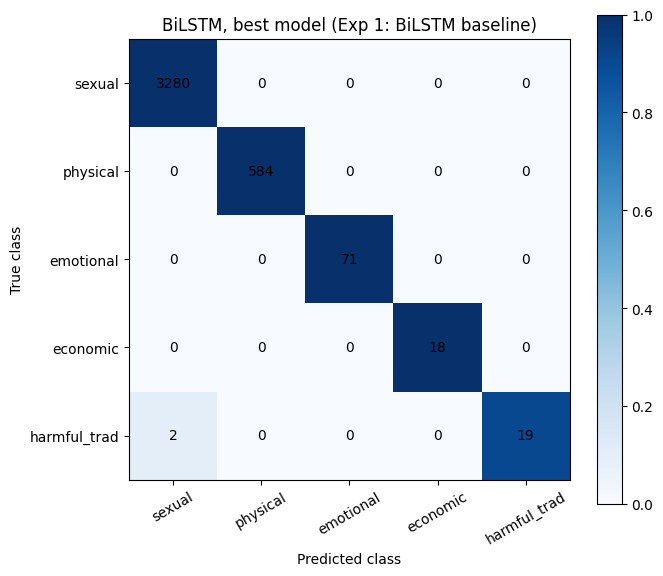

In [ ]:
print(classification_report(y_val, best_rnn_pred, labels=CLASS_NAMES, digits=3, zero_division=0))

cm = confusion_matrix(y_val, best_rnn_pred, labels=CLASS_NAMES)
short_names = ["sexual", "physical", "emotional", "economic", "harmful_trad"]

plt.figure(figsize=(7, 6))
plt.imshow(cm / cm.sum(axis=1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xticks(range(5), short_names, rotation=30)
plt.yticks(range(5), short_names)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title(f"BiLSTM, best model ({best_rnn_name})")
plt.colorbar()
plt.tight_layout()
plt.show()

### 9.11 Save results and compare with TF-IDF

We add the best BiLSTM to the shared `all_model_scores` table, so both models sit side by side.

In [ ]:
rnn_results_df.to_csv("results/bilstm_experiments.csv", index=False)

# Report the seed-averaged scores of the best BiLSTM experiment
best_row = rnn_results_df.loc[rnn_results_df["experiment"] == best_rnn_name].iloc[0]
all_model_scores.append({
    "model": "BiLSTM",
    "best_experiment": best_rnn_name,
    "accuracy": best_row["accuracy"],
    "macro_f1": best_row["macro_f1"],
    "macro_f1_std": best_row["macro_f1_std"],
})
display(pd.DataFrame(all_model_scores))

save_predictions("BiLSTM", best_rnn_pred, best_rnn_model.predict(X_val_seq, verbose=0), "val_predictions_bilstm.csv")

,model,best_experiment,accuracy,macro_f1,macro_f1_std
0,TF-IDF + Logistic Regression,Exp 3: words + word pairs,0.9952,0.9767,0.0000
1,BiLSTM,Exp 1: BiLSTM baseline,0.9991,0.9905,0.0009


Saved results/val_predictions_bilstm.csv (3974 rows, 2 wrong)


### 9.12 What we learned from the BiLSTM

- **Seeds matter:** the same BiLSTM scored between 0.982 and 1.000 depending only on the seed. A single run would have been misleading.
- **Class weights (Exp 1 vs Exp 2):** 0.989 vs 0.988 on average, with overlapping ranges. Unlike TF-IDF, class weights did not help the BiLSTM. Its learned word embeddings already pick up the small classes.
- **Both directions vs one (Exp 1 vs Exp 3, same settings):** BiLSTM 0.989 vs LSTM 0.977 on average. The one-direction LSTM was lower and much less stable (0.959 to 0.991). The ranges overlap, so the advantage of reading both ways is small but consistent with our expectation.
- **BiLSTM vs TF-IDF:** the BiLSTM beat TF-IDF (0.977) on every seed (lowest run 0.982), with 5 errors vs 19. Reading word order gives a small but consistent gain.
- **Learning curves:** training stopped after 4 epochs. Validation loss was lowest around epoch 2 and then rose slightly while training loss kept falling: mild overfitting, which early stopping handled by keeping the best weights.

## 10. Model 3: 1D CNN

**What it does:** small windows slide over the tweet, a few words at a time. Each window learns to fire on a short phrase, like "beat me" or "forced marriage", wherever it appears. The strongest signal from each window is kept, then used to pick the class.

**Why we include it:**
- **Our tweets are short** (99% have 61 words or fewer), so short phrases may be all that's needed.
- **CNN vs BiLSTM tells us what kind of task this is.** CNNs tend to win when a task depends on spotting key phrases; RNNs win when it needs the whole sentence ([Yin et al., 2017](https://arxiv.org/abs/1702.01923); [Kim, 2014](https://aclanthology.org/D14-1181/)).

**Setup:** same sequences, vocabulary, split and 3 seeds as the BiLSTM. No class weights, because they did not help the BiLSTM.

In [ ]:
cnn_results = []
cnn_trained = {}

def run_cnn_experiment(name, window_size=3):
    accs, f1s = [], []

    for seed in SEEDS:   # same 3 seeds as the BiLSTM
        keras.utils.set_random_seed(seed)
        model = keras.Sequential([
            keras.Input(shape=(MAX_LEN,)),
            layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),                   # word -> vector
            layers.Conv1D(filters=128, kernel_size=window_size, activation="relu"),   # 128 phrase detectors
            layers.GlobalMaxPooling1D(),                                              # keep each detector's strongest signal
            layers.Dropout(0.3),
            layers.Dense(len(CLASS_NAMES), activation="softmax"),
        ])
        model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

        early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
        history = model.fit(X_train_seq, y_train_ids, validation_data=(X_val_seq, y_val_ids),
                            epochs=10, batch_size=64, callbacks=[early_stop], verbose=0)

        val_pred = [CLASS_NAMES[i] for i in model.predict(X_val_seq, verbose=0).argmax(axis=1)]
        accs.append(accuracy_score(y_val, val_pred))
        f1s.append(f1_score(y_val, val_pred, labels=CLASS_NAMES, average="macro", zero_division=0))
        print(f"{name} | seed {seed:3d} | epochs {len(history.history['loss'])} | macro-F1 = {f1s[-1]:.4f}")

        if seed == SEEDS[0]:
            cnn_trained[name] = (model, history, val_pred)

    cnn_results.append({"experiment": name, "window_size": window_size,
                        "accuracy": round(np.mean(accs), 4),
                        "macro_f1": round(np.mean(f1s), 4),
                        "macro_f1_std": round(np.std(f1s), 4),
                        "macro_f1_min": round(min(f1s), 4),
                        "macro_f1_max": round(max(f1s), 4)})
    print(f"\n{name}  ->  average macro-F1 = {np.mean(f1s):.4f} (std {np.std(f1s):.4f})")
    return cnn_trained[name][2]

### 10.1 Two experiments: short vs longer phrases

- **Exp 1:** windows of **3 words** (for example "he beat me").
- **Exp 2:** windows of **5 words**, to test whether longer phrases carry more meaning.

In [ ]:
pred = run_cnn_experiment("Exp 1: CNN, 3-word windows", window_size=3)
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

pred = run_cnn_experiment("Exp 2: CNN, 5-word windows", window_size=5)
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

Exp 1: CNN, 3-word windows | seed  42 | epochs 5 | macro-F1 = 0.9904
Exp 1: CNN, 3-word windows | seed   7 | epochs 6 | macro-F1 = 0.9904
Exp 1: CNN, 3-word windows | seed 123 | epochs 7 | macro-F1 = 0.9904

Exp 1: CNN, 3-word windows  ->  average macro-F1 = 0.9904 (std 0.0000)
                              precision    recall  f1-score   support

             sexual_violence      1.000     1.000     1.000      3280
           Physical_violence      1.000     1.000     1.000       584
          emotional_violence      1.000     1.000     1.000        71
           economic_violence      1.000     1.000     1.000        18
Harmful_Traditional_practice      0.952     0.952     0.952        21

                    accuracy                          0.999      3974
                   macro avg      0.990     0.990     0.990      3974
                weighted avg      0.999     0.999     0.999      3974

Exp 2: CNN, 5-word windows | seed  42 | epochs 8 | macro-F1 = 0.9904
Exp 2: CNN, 5-word 

### 10.2 Best CNN and final comparison of our three models

We pick the best CNN by average macro-F1 over the 3 seeds, add it to the shared table, and save its validation predictions.

,experiment,window_size,accuracy,macro_f1,macro_f1_std,macro_f1_min,macro_f1_max
0,"Exp 1: CNN, 3-word windows",3,0.9995,0.9904,0.0000,0.9904,0.9904
1,"Exp 2: CNN, 5-word windows",5,0.9996,0.9920,0.0023,0.9904,0.9953


Best CNN: Exp 2: CNN, 5-word windows


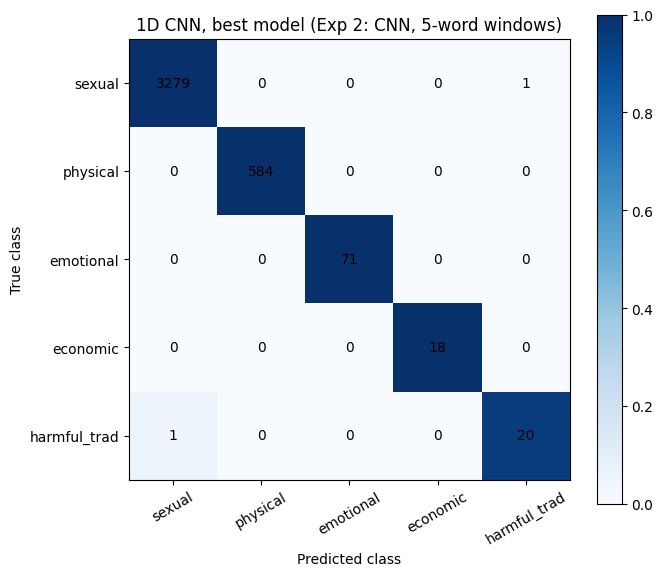

,model,best_experiment,accuracy,macro_f1,macro_f1_std
0,TF-IDF + Logistic Regression,Exp 3: words + word pairs,0.9952,0.9767,0.0000
1,BiLSTM,Exp 1: BiLSTM baseline,0.9991,0.9905,0.0009
2,1D CNN,"Exp 2: CNN, 5-word windows",0.9996,0.9920,0.0023


Saved results/val_predictions_cnn.csv (3974 rows, 2 wrong)


In [ ]:
cnn_results_df = pd.DataFrame(cnn_results)
display(cnn_results_df)
cnn_results_df.to_csv("results/cnn_experiments.csv", index=False)

best_cnn_name = cnn_results_df.loc[cnn_results_df["macro_f1"].idxmax(), "experiment"]
best_cnn_model, best_cnn_history, best_cnn_pred = cnn_trained[best_cnn_name]
print("Best CNN:", best_cnn_name)

# Confusion matrix of the best CNN
cm = confusion_matrix(y_val, best_cnn_pred, labels=CLASS_NAMES)
plt.figure(figsize=(7, 6))
plt.imshow(cm / cm.sum(axis=1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xticks(range(5), short_names, rotation=30)
plt.yticks(range(5), short_names)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title(f"1D CNN, best model ({best_cnn_name})")
plt.colorbar()
plt.tight_layout()
plt.show()

# Add the seed-averaged scores of the best CNN and show all three models side by side
best_row = cnn_results_df.loc[cnn_results_df["experiment"] == best_cnn_name].iloc[0]
all_model_scores.append({
    "model": "1D CNN",
    "best_experiment": best_cnn_name,
    "accuracy": best_row["accuracy"],
    "macro_f1": best_row["macro_f1"],
    "macro_f1_std": best_row["macro_f1_std"],
})
final_table = pd.DataFrame(all_model_scores)
display(final_table)
final_table.to_csv("results/all_models_comparison.csv", index=False)

save_predictions("1D CNN", best_cnn_pred, best_cnn_model.predict(X_val_seq, verbose=0), "val_predictions_cnn.csv")

### 10.3 What we learned

- **3 vs 5-word windows:** 0.990 vs 0.992 on average, a difference of about one tweet. The 3-word CNN gave exactly the same score on all 3 seeds, so it is very stable. Longer phrases did not clearly help.
- **CNN vs BiLSTM:** 0.992 vs 0.989 on average, with overlapping ranges. They tie. A model that only looks at short phrases does as well as one that reads the whole tweet, so short local phrases carry most of the information.
- **Neural models vs TF-IDF:** both neural models beat TF-IDF (0.977) on every seed: 2 and 5 errors vs 19. The gain is small but consistent.
- **Answer to our research question:** sequential models help, but only a little. Most of the signal is in a few keywords and short phrases, so on this dataset a simple baseline already comes close. All models still miss about one harmful-practice tweet, which is worth examining in the error analysis.

## 11. Model 4: CNN-BiLSTM with attention

**What it does:** it combines the two ideas we have tested so far, then adds attention.
1. Each word becomes a vector (embedding), as before.
2. A **convolution** with 3-word windows turns the words into **phrase features** ("beat me", "forced marriage"). Unlike the CNN in Section 10, it does not throw away the order: every position keeps its phrase feature.
3. A **BiLSTM** reads those phrase features left to right and right to left, so each position knows its context.
4. **Attention** gives every position a score for how useful it is, turns the scores into weights that add up to 1, and builds the tweet's summary as a weighted average. Padding is ignored.

**Why we include it:**
- **Our results point to both phrases and context.** The CNN (short phrases) and the BiLSTM (whole sentence) tied at about 0.99. Convolution followed by an LSTM is the C-LSTM idea ([Zhou et al., 2015](https://arxiv.org/abs/1511.08630)): local phrases first, then word order on top.
- **Attention instead of "last memory" or "strongest signal".** The BiLSTM summarised a tweet by its final memory, the CNN by the strongest detector. Attention lets the model focus on the important part wherever it is in the tweet ([Bahdanau et al., 2015](https://arxiv.org/abs/1409.0473); [Yang et al., 2016](https://aclanthology.org/N16-1174/)).
- **It helps the error analysis.** The attention weights show which words the model looked at, so for a wrong prediction we can see whether it was fooled by a keyword (Section 14).

**Setup:** same sequences, vocabulary, split and 3 seeds as Models 2 and 3. No class weights, because they did not help the BiLSTM.

In [ ]:
from keras import ops

@keras.saving.register_keras_serializable()
class AttentionPooling(layers.Layer):
    # score for each word = u . tanh(W h + b), softmax over the words, weighted average (Yang et al., 2016)
    def build(self, input_shape):
        d = input_shape[-1]
        self.W = self.add_weight(name="W", shape=(d, d), initializer="glorot_uniform")
        self.b = self.add_weight(name="b", shape=(d,), initializer="zeros")
        self.u = self.add_weight(name="u", shape=(d,), initializer="glorot_uniform")

    def call(self, h, mask=None):
        scores = ops.sum(ops.tanh(ops.matmul(h, self.W) + self.b) * self.u, axis=-1)   # one score per word
        if mask is not None:
            scores = ops.where(mask, scores, ops.full_like(scores, -1e9))              # padding gets ~0 weight
        weights = ops.softmax(scores, axis=-1)                                         # weights add up to 1
        summary = ops.sum(h * ops.expand_dims(weights, -1), axis=1)                    # weighted average
        return summary, weights

    def compute_mask(self, inputs, mask=None):
        return None

@keras.saving.register_keras_serializable()
class MaskedMaxPooling(layers.Layer):
    # Strongest signal per feature, ignoring padding (used in Experiment 2 instead of attention)
    def call(self, h, mask=None):
        if mask is not None:
            h = ops.where(ops.expand_dims(mask, -1), h, ops.full_like(h, -1e9))
        return ops.max(h, axis=1)

    def compute_mask(self, inputs, mask=None):
        return None

def build_model4(use_conv=True, pooling="attention"):
    inp = keras.Input(shape=(MAX_LEN,), dtype="int64")
    pad_mask = layers.Lambda(lambda t: ops.not_equal(t, 0), name="padding_mask")(inp)   # True for real words
    x = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128)(inp)
    if use_conv:
        x = layers.Conv1D(filters=128, kernel_size=3, padding="same", activation="relu")(x)   # phrase features
        x = layers.Dropout(0.2)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x, mask=pad_mask)    # context, both directions

    if pooling == "attention":
        summary, att_weights = AttentionPooling(name="attention")(x, mask=pad_mask)
    else:
        summary, att_weights = MaskedMaxPooling()(x, mask=pad_mask), None

    x = layers.Dropout(0.3)(summary)
    out = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    attention_model = keras.Model(inp, att_weights) if att_weights is not None else None
    return model, attention_model

build_model4()[0].summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_16        │ (None, 64, 128)   │  2,560,000 │ input_layer_16[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 64, 128)   │     49,280 │ embedding_16[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 64, 128)   │          0 │ conv1d_6[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, 64)        │          0 │ input_layer_16[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_7     │ (None, 64, 128)   │     98,816 │ dropout_16[0][0], │
│ (Bidirectional)     │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ [(None, 128),     │     16,640 │ bidirectional_7[… │
│ (AttentionPooling)  │ (None, 64)]       │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 128)       │          0 │ attention[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 5)         │        645 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,725,381 (10.40 MB)

 Trainable params: 2,725,381 (10.40 MB)

 Non-trainable params: 0 (0.00 B)

### 11.1 One function for every experiment

Same as `run_rnn_experiment`: each experiment trains a fresh model with the 3 seeds, up to 10 epochs, batch 64, early stopping on validation loss (patience 2), and keeps the seed-42 run for curves, confusion matrix and predictions.

We also keep the **probabilities** of the seed-42 run, which we need for the ROC curves in Section 13.

In [ ]:
m4_results = []
m4_trained = {}   # name -> (model, history, val_pred, val_probs, attention_model) for the seed-42 run

def run_model4_experiment(name, use_conv=True, pooling="attention"):
    accs, f1s = [], []
    for seed in SEEDS:
        keras.utils.set_random_seed(seed)
        model, attention_model = build_model4(use_conv, pooling)
        early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
        history = model.fit(X_train_seq, y_train_ids, validation_data=(X_val_seq, y_val_ids),
                            epochs=10, batch_size=64, callbacks=[early_stop], verbose=0)

        val_probs = model.predict(X_val_seq, verbose=0)
        val_pred = [CLASS_NAMES[i] for i in val_probs.argmax(axis=1)]
        accs.append(accuracy_score(y_val, val_pred))
        f1s.append(f1_score(y_val, val_pred, labels=CLASS_NAMES, average="macro", zero_division=0))
        print(f"{name} | seed {seed:3d} | epochs {len(history.history['loss'])} | macro-F1 = {f1s[-1]:.4f}")

        if seed == SEEDS[0]:
            m4_trained[name] = (model, history, val_pred, val_probs, attention_model)

    m4_results.append({"experiment": name,
                       "convolution": use_conv, "pooling": pooling,
                       "accuracy": round(np.mean(accs), 4),
                       "macro_f1": round(np.mean(f1s), 4),
                       "macro_f1_std": round(np.std(f1s), 4),
                       "macro_f1_min": round(min(f1s), 4),
                       "macro_f1_max": round(max(f1s), 4)})
    print(f"\n{name}  ->  average macro-F1 = {np.mean(f1s):.4f} (std {np.std(f1s):.4f})")
    return m4_trained[name][2]

### 11.2 Experiment 1: CNN-BiLSTM + attention (full model)

In [ ]:
pred = run_model4_experiment("Exp 1: CNN-BiLSTM + attention")
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

Exp 1: CNN-BiLSTM + attention | seed  42 | epochs 10 | macro-F1 = 0.9951
Exp 1: CNN-BiLSTM + attention | seed   7 | epochs 5 | macro-F1 = 0.9888
Exp 1: CNN-BiLSTM + attention | seed 123 | epochs 7 | macro-F1 = 0.9874

Exp 1: CNN-BiLSTM + attention  ->  average macro-F1 = 0.9904 (std 0.0033)
                              precision    recall  f1-score   support

             sexual_violence      1.000     1.000     1.000      3280
           Physical_violence      1.000     1.000     1.000       584
          emotional_violence      1.000     1.000     1.000        71
           economic_violence      1.000     1.000     1.000        18
Harmful_Traditional_practice      1.000     0.952     0.976        21

                    accuracy                          1.000      3974
                   macro avg      1.000     0.990     0.995      3974
                weighted avg      1.000     1.000     1.000      3974



### 11.3 Experiment 2: does attention help? (max pooling instead)

**Change:** attention is replaced by max pooling (keep each feature's strongest signal, like the CNN in Section 10). Everything else stays the same.

- **If Exp 1 clearly wins:** weighting the words by importance helps.
- **If they tie:** the strongest phrase is enough, which fits the idea that the task is keyword-driven.

In [ ]:
pred = run_model4_experiment("Exp 2: CNN-BiLSTM + max pooling", pooling="max")
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

Exp 2: CNN-BiLSTM + max pooling | seed  42 | epochs 4 | macro-F1 = 0.9949
Exp 2: CNN-BiLSTM + max pooling | seed   7 | epochs 5 | macro-F1 = 0.9949
Exp 2: CNN-BiLSTM + max pooling | seed 123 | epochs 6 | macro-F1 = 0.9886

Exp 2: CNN-BiLSTM + max pooling  ->  average macro-F1 = 0.9928 (std 0.0030)
                              precision    recall  f1-score   support

             sexual_violence      1.000     0.999     1.000      3280
           Physical_violence      0.998     0.998     0.998       584
          emotional_violence      1.000     1.000     1.000        71
           economic_violence      1.000     1.000     1.000        18
Harmful_Traditional_practice      0.955     1.000     0.977        21

                    accuracy                          0.999      3974
                   macro avg      0.991     1.000     0.995      3974
                weighted avg      0.999     0.999     0.999      3974



### 11.4 Experiment 3: does the convolution help? (BiLSTM + attention, no CNN)

**Change:** the convolution layer is removed, so the BiLSTM reads the words directly, then attention summarises. Compared with Exp 1, this tells us whether building phrase features first adds anything. Compared with the plain BiLSTM in Section 9, it tells us whether attention beats the BiLSTM's final memory.

In [ ]:
pred = run_model4_experiment("Exp 3: BiLSTM + attention (no CNN)", use_conv=False)
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

Exp 3: BiLSTM + attention (no CNN) | seed  42 | epochs 5 | macro-F1 = 0.9904
Exp 3: BiLSTM + attention (no CNN) | seed   7 | epochs 5 | macro-F1 = 0.9949
Exp 3: BiLSTM + attention (no CNN) | seed 123 | epochs 7 | macro-F1 = 0.9904

Exp 3: BiLSTM + attention (no CNN)  ->  average macro-F1 = 0.9919 (std 0.0021)
                              precision    recall  f1-score   support

             sexual_violence      1.000     1.000     1.000      3280
           Physical_violence      1.000     1.000     1.000       584
          emotional_violence      1.000     1.000     1.000        71
           economic_violence      1.000     1.000     1.000        18
Harmful_Traditional_practice      0.952     0.952     0.952        21

                    accuracy                          0.999      3974
                   macro avg      0.990     0.990     0.990      3974
                weighted avg      0.999     0.999     0.999      3974



### 11.5 Compare the three experiments

,experiment,convolution,pooling,accuracy,macro_f1,macro_f1_std,macro_f1_min,macro_f1_max
0,Exp 1: CNN-BiLSTM + attention,True,attention,0.9993,0.9904,0.0033,0.9874,0.9951
1,Exp 2: CNN-BiLSTM + max pooling,True,max,0.9992,0.9928,0.0030,0.9886,0.9949
2,Exp 3: BiLSTM + attention (no CNN),False,attention,0.9995,0.9919,0.0021,0.9904,0.9949


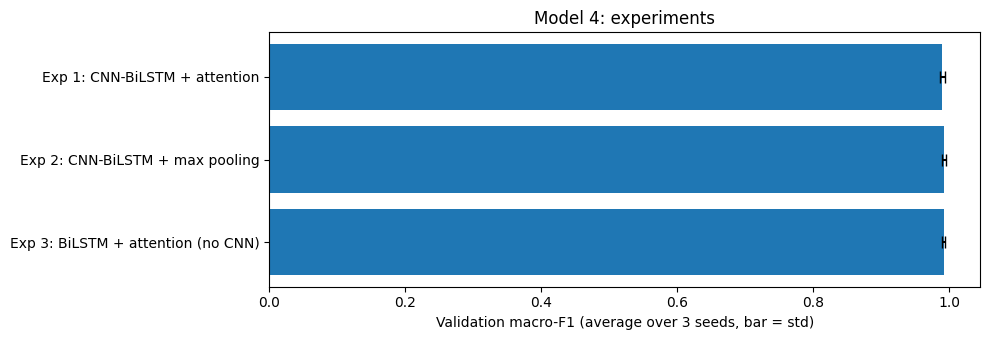

Best experiment: Exp 2: CNN-BiLSTM + max pooling


In [ ]:
m4_results_df = pd.DataFrame(m4_results)
display(m4_results_df)
m4_results_df.to_csv("results/model4_experiments.csv", index=False)

plt.figure(figsize=(10, 3.5))
plt.barh(m4_results_df["experiment"], m4_results_df["macro_f1"],
         xerr=m4_results_df["macro_f1_std"], capsize=4)
plt.xlabel("Validation macro-F1 (average over 3 seeds, bar = std)")
plt.title("Model 4: experiments")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

best_m4_name = m4_results_df.loc[m4_results_df["macro_f1"].idxmax(), "experiment"]
print("Best experiment:", best_m4_name)

### 11.6 Learning curves and the best Model 4 in detail

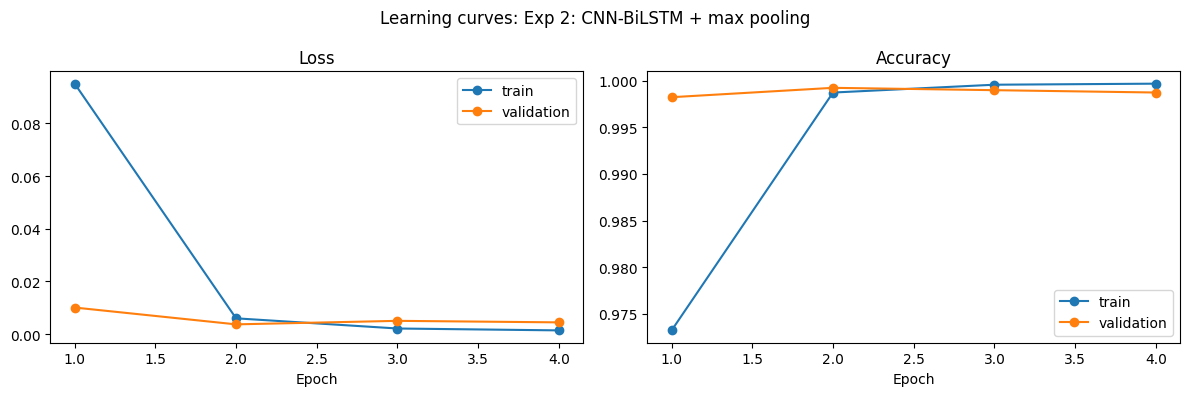

                              precision    recall  f1-score   support

             sexual_violence      1.000     0.999     1.000      3280
           Physical_violence      0.998     0.998     0.998       584
          emotional_violence      1.000     1.000     1.000        71
           economic_violence      1.000     1.000     1.000        18
Harmful_Traditional_practice      0.955     1.000     0.977        21

                    accuracy                          0.999      3974
                   macro avg      0.991     1.000     0.995      3974
                weighted avg      0.999     0.999     0.999      3974



In [ ]:
best_m4_model, best_m4_history, best_m4_pred, best_m4_probs, _ = m4_trained[best_m4_name]
hist = pd.DataFrame(best_m4_history.history)
epochs = range(1, len(hist) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, hist["loss"], marker="o", label="train")
axes[0].plot(epochs, hist["val_loss"], marker="o", label="validation")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(epochs, hist["accuracy"], marker="o", label="train")
axes[1].plot(epochs, hist["val_accuracy"], marker="o", label="validation")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.suptitle(f"Learning curves: {best_m4_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_val, best_m4_pred, labels=CLASS_NAMES, digits=3, zero_division=0))

In [ ]:
best_row = m4_results_df.loc[m4_results_df["experiment"] == best_m4_name].iloc[0]
all_model_scores.append({
    "model": "CNN-BiLSTM + attention",
    "best_experiment": best_m4_name,
    "accuracy": best_row["accuracy"],
    "macro_f1": best_row["macro_f1"],
    "macro_f1_std": best_row["macro_f1_std"],
})
display(pd.DataFrame(all_model_scores))
save_predictions("CNN-BiLSTM + attention", best_m4_pred, best_m4_probs, "val_predictions_cnn_bilstm_attention.csv")

# The attention model of Experiment 1 is used in the error analysis (Section 14)
m4_attention_model = m4_trained["Exp 1: CNN-BiLSTM + attention"][4]
m4_attention_clf = m4_trained["Exp 1: CNN-BiLSTM + attention"][0]

,model,best_experiment,accuracy,macro_f1,macro_f1_std
0,TF-IDF + Logistic Regression,Exp 3: words + word pairs,0.9952,0.9767,0.0000
1,BiLSTM,Exp 1: BiLSTM baseline,0.9991,0.9905,0.0009
2,1D CNN,"Exp 2: CNN, 5-word windows",0.9996,0.9920,0.0023
3,CNN-BiLSTM + attention,Exp 2: CNN-BiLSTM + max pooling,0.9992,0.9928,0.0030


Saved results/val_predictions_cnn_bilstm_attention.csv (3974 rows, 3 wrong)


## 12. Model 5: fine-tuned Transformer (DistilBERT)

**What it does:** a Transformer reads the whole tweet at once. With **self-attention**, every word looks directly at every other word, so it does not have to pass information along word by word like the LSTM ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)). Most importantly, it does not start from zero: it was **pretrained** on a large amount of English text (books and Wikipedia), so it already knows that "slapped", "punched" and "beats" are related. We add a small classification layer on top and **fine-tune** the whole network on our tweets ([Devlin et al., 2019](https://aclanthology.org/N19-1423/)).

We use **DistilBERT** ([Sanh et al., 2019](https://arxiv.org/abs/1910.01108)), a smaller version of BERT with 6 instead of 12 layers. It keeps about 97% of BERT's language-understanding performance while being 40% smaller and 60% faster, so it trains in a few minutes on Colab's free T4 GPU.

**Why we include it:**
- **It is the only model with prior knowledge of language.** Models 1–4 learn every word from our 35,676 training tweets alone. If a tweet describes abuse with words that are rare in the training data, they have little to go on. DistilBERT can still recognise the meaning. This is exactly what the keyword tests in Section 14 check.
- **It handles unknown and misspelled words.** It splits words into known pieces ("humilated" → "hu", "##mi", "##lated"), while Models 2–4 turn every unknown word into the same "unknown" ID.
- **It is the standard strong model for tweet classification.** Fine-tuned Transformers are the reference point on tweet benchmarks such as TweetEval ([Barbieri et al., 2020](https://aclanthology.org/2020.findings-emnlp.148/)).

**Setup:** same split and 3 seeds. The model trains with PyTorch through the Hugging Face `transformers` library ([Wolf et al., 2020](https://aclanthology.org/2020.emnlp-demos.6/)), because TensorFlow support was removed from that library. As with early stopping in the other models, we keep the epoch with the lowest validation loss.

In [ ]:
import time
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()   # hide the expected "some weights are newly initialized" message

TRANSFORMER_NAME = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"    # mixed precision: faster on GPU

print("PyTorch device:", device)
if device.type == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"Free GPU memory: {free / 1e9:.1f} GB of {total / 1e9:.1f} GB")
    if free < 4e9:
        print("WARNING: less than 4 GB free. Restart the runtime and make sure the memory-growth lines "
              "in the TensorFlow import cell (Section 9) run before any model is trained.")
else:
    print("WARNING: no GPU. Fine-tuning DistilBERT on CPU takes hours. Use Runtime > Change runtime type > T4 GPU.")

PyTorch device: cuda
Free GPU memory: 9.6 GB of 15.6 GB


### 12.1 Turn tweets into subword tokens

DistilBERT has its own tokenizer and vocabulary (about 30,000 subwords), so it does not use our `TextVectorization` sequences. We check how many tokens tweets need and choose the maximum length to cover more than 99% of them.

**Dynamic padding:** instead of padding every tweet to the maximum length, each batch is padded only to its own longest tweet. Most tweets are short, so this roughly halves training time.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_NAME)

train_token_ids = tokenizer(list(X_train_text), truncation=False)["input_ids"]
token_lengths = np.array([len(ids) for ids in train_token_ids])
print("Tokens per tweet: median", int(np.median(token_lengths)),
      "| 99th percentile", int(np.percentile(token_lengths, 99)), "| longest", token_lengths.max())

MAX_TOKENS = 128
print(f"Share of training tweets that fit in {MAX_TOKENS} tokens: {(token_lengths <= MAX_TOKENS).mean():.4f}")

print("\nExample:", X_train_text.iloc[0][:80])
print("Tokens :", tokenizer.tokenize(X_train_text.iloc[0])[:20])

def tokenize(texts):
    return tokenizer(list(texts), truncation=True, max_length=MAX_TOKENS)["input_ids"]

tr_token_ids = tokenize(X_train_text)
va_token_ids = tokenize(X_val_text)

def make_batch(id_lists):
    # Pad a list of token-id lists to the longest one in this batch
    longest = max(len(ids) for ids in id_lists)
    input_ids = torch.full((len(id_lists), longest), tokenizer.pad_token_id, dtype=torch.long)
    attention_mask = torch.zeros((len(id_lists), longest), dtype=torch.long)
    for i, ids in enumerate(id_lists):
        input_ids[i, :len(ids)] = torch.tensor(ids)
        attention_mask[i, :len(ids)] = 1
    return input_ids.to(device), attention_mask.to(device)

@torch.no_grad()
def transformer_predict_ids(model, id_lists, batch_size=128):
    # Returns class probabilities in CLASS_NAMES order. Sorting by length makes batches compact.
    model.eval()
    order = np.argsort([len(ids) for ids in id_lists])
    probs = np.zeros((len(id_lists), len(CLASS_NAMES)), dtype=np.float32)
    for start in range(0, len(order), batch_size):
        idx = order[start:start + batch_size]
        input_ids, attention_mask = make_batch([id_lists[i] for i in idx])
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        probs[idx] = torch.softmax(logits.float(), dim=-1).cpu().numpy()
    return probs

def transformer_predict_texts(model, texts):
    return transformer_predict_ids(model, tokenize(texts))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokens per tweet: median 56 | 99th percentile 82 | longest 145
Share of training tweets that fit in 128 tokens: 0.9999

Example: Had a dream i got raped last night. By a guy i work with. Actually a guy i smoke
Tokens : ['had', 'a', 'dream', 'i', 'got', 'raped', 'last', 'night', '.', 'by', 'a', 'guy', 'i', 'work', 'with', '.', 'actually', 'a', 'guy', 'i']


### 12.2 One function for every experiment

For each seed: load the pretrained DistilBERT, add a 5-class output layer, and train.
- **Optimizer:** AdamW with a small learning rate (fine-tuning only adjusts weights that are already good). The learning rate warms up over the first 10% of steps and then decreases linearly to 0, the standard recipe from the BERT paper.
- **Up to 3 epochs, batch 32.** Pretrained models usually need only 2–4 epochs.
- **Keep the best epoch** (lowest validation loss), like early stopping in Models 2–4.
- **No class weights**, for the same reason as Models 2–4.

In [ ]:
m5_results = []
m5_trained = {}   # name -> (model, history, val_pred, val_probs) for the seed-42 run
tr_labels = torch.tensor(y_train_ids, dtype=torch.long)

def run_transformer_experiment(name, learning_rate=2e-5, epochs=3, batch_size=32, freeze_encoder=False):
    accs, f1s, minutes = [], [], []
    for seed in SEEDS:
        keras.utils.set_random_seed(seed)   # also seeds Python and NumPy
        torch.manual_seed(seed)
        model = AutoModelForSequenceClassification.from_pretrained(TRANSFORMER_NAME, num_labels=len(CLASS_NAMES)).to(device)
        if freeze_encoder:   # train only the new output layers, keep DistilBERT's weights fixed
            for p in model.base_model.parameters():
                p.requires_grad = False

        params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(params, lr=learning_rate, weight_decay=0.01)
        steps = epochs * int(np.ceil(len(tr_token_ids) / batch_size))
        scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * steps), steps)
        scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
        loss_fn = torch.nn.CrossEntropyLoss()
        shuffler = np.random.default_rng(seed)

        history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
        best_val_loss, best_state = float("inf"), None
        start = time.time()
        for epoch in range(epochs):
            model.train()
            order = shuffler.permutation(len(tr_token_ids))
            total_loss, correct = 0.0, 0
            for b in range(0, len(order), batch_size):
                idx = order[b:b + batch_size]
                input_ids, attention_mask = make_batch([tr_token_ids[i] for i in idx])
                labels = tr_labels[idx].to(device)
                optimizer.zero_grad()
                with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
                loss = loss_fn(logits.float(), labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(params, 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                total_loss += loss.item() * len(idx)
                correct += (logits.argmax(-1) == labels).sum().item()

            val_probs = transformer_predict_ids(model, va_token_ids)
            val_loss = float(-np.mean(np.log(val_probs[np.arange(len(y_val_ids)), y_val_ids] + 1e-12)))
            history["loss"].append(total_loss / len(order))
            history["accuracy"].append(correct / len(order))
            history["val_loss"].append(val_loss)
            history["val_accuracy"].append(float((val_probs.argmax(1) == y_val_ids).mean()))
            if val_loss < best_val_loss:   # keep the best epoch
                best_val_loss = val_loss
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

        model.load_state_dict(best_state)
        minutes.append((time.time() - start) / 60)
        val_probs = transformer_predict_ids(model, va_token_ids)
        val_pred = [CLASS_NAMES[i] for i in val_probs.argmax(axis=1)]
        accs.append(accuracy_score(y_val, val_pred))
        f1s.append(f1_score(y_val, val_pred, labels=CLASS_NAMES, average="macro", zero_division=0))
        best_epoch = int(np.argmin(history["val_loss"])) + 1
        print(f"{name} | seed {seed:3d} | best epoch {best_epoch} | macro-F1 = {f1s[-1]:.4f} | {minutes[-1]:.1f} min")

        if seed == SEEDS[0]:
            m5_trained[name] = (model, history, val_pred, val_probs)
        else:
            del model
        del best_state
        if device.type == "cuda":
            torch.cuda.empty_cache()

    m5_results.append({"experiment": name, "learning_rate": learning_rate, "frozen_encoder": freeze_encoder,
                       "accuracy": round(np.mean(accs), 4),
                       "macro_f1": round(np.mean(f1s), 4),
                       "macro_f1_std": round(np.std(f1s), 4),
                       "macro_f1_min": round(min(f1s), 4),
                       "macro_f1_max": round(max(f1s), 4),
                       "minutes_per_run": round(np.mean(minutes), 1)})
    print(f"\n{name}  ->  average macro-F1 = {np.mean(f1s):.4f} (std {np.std(f1s):.4f})")
    return m5_trained[name][2]

### 12.3 Experiment 1: full fine-tuning

All of DistilBERT's weights are updated on our tweets, with learning rate 2e-5 (a standard value for BERT-type models).

In [ ]:
pred = run_transformer_experiment("Exp 1: DistilBERT, full fine-tuning", learning_rate=2e-5)
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Exp 1: DistilBERT, full fine-tuning | seed  42 | best epoch 1 | macro-F1 = 0.9944 | 5.0 min


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Exp 1: DistilBERT, full fine-tuning | seed   7 | best epoch 3 | macro-F1 = 0.9946 | 4.8 min


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Exp 1: DistilBERT, full fine-tuning | seed 123 | best epoch 3 | macro-F1 = 1.0000 | 4.8 min

Exp 1: DistilBERT, full fine-tuning  ->  average macro-F1 = 0.9963 (std 0.0026)
                              precision    recall  f1-score   support

             sexual_violence      1.000     0.999     1.000      3280
           Physical_violence      0.998     1.000     0.999       584
          emotional_violence      1.000     1.000     1.000        71
           economic_violence      0.947     1.000     0.973        18
Harmful_Traditional_practice      1.000     1.000     1.000        21

                    accuracy                          0.999      3974
                   macro avg      0.989     1.000     0.994      3974
                weighted avg      1.000     0.999     1.000      3974



### 12.4 Experiment 2: frozen DistilBERT (pretrained knowledge only)

**Change:** DistilBERT's weights are kept fixed; only the new output layers are trained (with a larger learning rate, 1e-3, since only a few weights learn).

**Why:** it separates two things. Exp 2 shows how far the **general English knowledge** from pretraining gets us without adapting to tweets about violence. The gap between Exp 1 and Exp 2 shows how much **learning from our own data** adds.

In [ ]:
pred = run_transformer_experiment("Exp 2: DistilBERT, frozen encoder", learning_rate=1e-3, freeze_encoder=True)
print(classification_report(y_val, pred, labels=CLASS_NAMES, digits=3, zero_division=0))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Exp 2: DistilBERT, frozen encoder | seed  42 | best epoch 3 | macro-F1 = 0.8595 | 1.3 min


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Exp 2: DistilBERT, frozen encoder | seed   7 | best epoch 3 | macro-F1 = 0.8656 | 1.2 min


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Exp 2: DistilBERT, frozen encoder | seed 123 | best epoch 3 | macro-F1 = 0.8697 | 1.2 min

Exp 2: DistilBERT, frozen encoder  ->  average macro-F1 = 0.8649 (std 0.0042)
                              precision    recall  f1-score   support

             sexual_violence      0.983     0.993     0.988      3280
           Physical_violence      0.972     0.961     0.966       584
          emotional_violence      0.868     0.648     0.742        71
           economic_violence      0.875     0.778     0.824        18
Harmful_Traditional_practice      0.933     0.667     0.778        21

                    accuracy                          0.979      3974
                   macro avg      0.926     0.809     0.860      3974
                weighted avg      0.979     0.979     0.979      3974



### 12.5 Compare the experiments

,experiment,learning_rate,frozen_encoder,accuracy,macro_f1,macro_f1_std,macro_f1_min,macro_f1_max,minutes_per_run
0,"Exp 1: DistilBERT, full fine-tuning",0.00002,False,0.9997,0.9963,0.0026,0.9944,1.0000,4.9
1,"Exp 2: DistilBERT, frozen encoder",0.00100,True,0.9801,0.8649,0.0042,0.8595,0.8697,1.3


Best experiment: Exp 1: DistilBERT, full fine-tuning


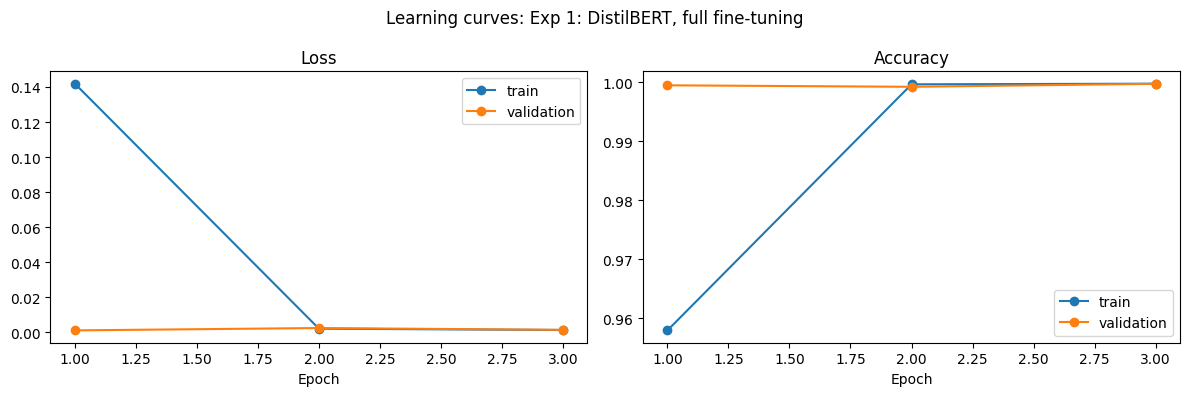

                              precision    recall  f1-score   support

             sexual_violence      1.000     0.999     1.000      3280
           Physical_violence      0.998     1.000     0.999       584
          emotional_violence      1.000     1.000     1.000        71
           economic_violence      0.947     1.000     0.973        18
Harmful_Traditional_practice      1.000     1.000     1.000        21

                    accuracy                          0.999      3974
                   macro avg      0.989     1.000     0.994      3974
                weighted avg      1.000     0.999     1.000      3974



In [ ]:
m5_results_df = pd.DataFrame(m5_results)
display(m5_results_df)
m5_results_df.to_csv("results/transformer_experiments.csv", index=False)

best_m5_name = m5_results_df.loc[m5_results_df["macro_f1"].idxmax(), "experiment"]
best_m5_model, best_m5_history, best_m5_pred, best_m5_probs = m5_trained[best_m5_name]
print("Best experiment:", best_m5_name)

hist = pd.DataFrame(best_m5_history)
epochs = range(1, len(hist) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, hist["loss"], marker="o", label="train")
axes[0].plot(epochs, hist["val_loss"], marker="o", label="validation")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(epochs, hist["accuracy"], marker="o", label="train")
axes[1].plot(epochs, hist["val_accuracy"], marker="o", label="validation")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.suptitle(f"Learning curves: {best_m5_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_val, best_m5_pred, labels=CLASS_NAMES, digits=3, zero_division=0))

In [ ]:
best_row = m5_results_df.loc[m5_results_df["experiment"] == best_m5_name].iloc[0]
all_model_scores.append({
    "model": "DistilBERT (fine-tuned)",
    "best_experiment": best_m5_name,
    "accuracy": best_row["accuracy"],
    "macro_f1": best_row["macro_f1"],
    "macro_f1_std": best_row["macro_f1_std"],
})
display(pd.DataFrame(all_model_scores))
save_predictions("DistilBERT", best_m5_pred, best_m5_probs, "val_predictions_distilbert.csv")

,model,best_experiment,accuracy,macro_f1,macro_f1_std
0,TF-IDF + Logistic Regression,Exp 3: words + word pairs,0.9952,0.9767,0.0000
1,BiLSTM,Exp 1: BiLSTM baseline,0.9991,0.9905,0.0009
2,1D CNN,"Exp 2: CNN, 5-word windows",0.9996,0.9920,0.0023
3,CNN-BiLSTM + attention,Exp 2: CNN-BiLSTM + max pooling,0.9992,0.9928,0.0030
4,DistilBERT (fine-tuned),"Exp 1: DistilBERT, full fine-tuning",0.9997,0.9963,0.0026


Saved results/val_predictions_distilbert.csv (3974 rows, 2 wrong)


### 12.6 What we learned from DistilBERT

*(Fill in after running.)*

- **Full fine-tuning vs frozen (Exp 1 vs Exp 2):** ...
- **Best epoch:** how many epochs did it need? ...
- **DistilBERT vs Models 1–4:** ...
- **Cost:** about 66 million parameters and a GPU, against about 2.7 million for the BiLSTM and seconds on a CPU for TF-IDF. ...

# PART 3. COMPARISON AND ERROR ANALYSIS

## 13. Final comparison of all five models

### 13.1 Why these metrics

- **Macro-F1 (main metric):** the average of the five per-class F1 scores, each counted equally. The three small classes are only 2.8% of tweets, yet they count for 3/5 of the score. Always predicting `sexual_violence` gets 82.5% accuracy but only 0.18 macro-F1 (Section 8.1).
- **Accuracy:** reported for completeness, but it is dominated by the largest class.
- **Per-class F1 of the three small classes:** this is where the models differ.
- **ROC-AUC and PR-AUC (one class vs the rest):** these use the probabilities, not just the predicted class, so they show how well a model *ranks* tweets for each class. PR-AUC (average precision) is more informative than ROC-AUC when a class is rare ([Saito & Rehmsmeier, 2015](https://doi.org/10.1371/journal.pone.0118432)).
- **Seed spread (std, min, max):** how stable a model is.
- **95% bootstrap interval and McNemar's test:** whether the differences between models are larger than chance. With only 18 economic and 21 harmful-practice tweets, one tweet moves a class F1 by about 2.5 points.

As in Sections 9 and 10, the detailed analysis (confusion matrices, curves, errors) uses the **seed-42 run** of each model's best experiment.

In [ ]:
from sklearn.metrics import roc_curve, auc, average_precision_score, precision_recall_curve
from sklearn.preprocessing import label_binarize
from scipy.stats import binomtest

# Seed-42 predictions and probabilities of each model's best experiment, all in CLASS_NAMES order
lr_order = [list(best_model.classes_).index(name) for name in CLASS_NAMES]   # scikit-learn sorts classes alphabetically

def lr_probs_for(texts):
    return best_model.predict_proba(best_tfidf.transform(pd.Series(texts).astype(str)))[:, lr_order]

def keras_probs_for(model, texts):
    return model.predict(vectorizer(np.array(texts, dtype=object).astype(str)).numpy(), verbose=0)

final_models = {
    "TF-IDF + LR":            {"probs": lr_probs_for(X_val_text),
                               "predict": lr_probs_for,
                               "params": best_model.coef_.size + best_model.intercept_.size},
    "BiLSTM":                 {"probs": best_rnn_model.predict(X_val_seq, verbose=0),
                               "predict": lambda t: keras_probs_for(best_rnn_model, t),
                               "params": best_rnn_model.count_params()},
    "1D CNN":                 {"probs": best_cnn_model.predict(X_val_seq, verbose=0),
                               "predict": lambda t: keras_probs_for(best_cnn_model, t),
                               "params": best_cnn_model.count_params()},
    "CNN-BiLSTM + attention": {"probs": best_m4_probs,
                               "predict": lambda t: keras_probs_for(best_m4_model, t),
                               "params": best_m4_model.count_params()},
    "DistilBERT":             {"probs": best_m5_probs,
                               "predict": lambda t: transformer_predict_texts(best_m5_model, t),
                               "params": sum(p.numel() for p in best_m5_model.parameters())},   # ~67M for DistilBERT
}
MODEL_ORDER = list(final_models)
for m in MODEL_ORDER:
    final_models[m]["pred_ids"] = final_models[m]["probs"].argmax(axis=1)

# Check: the predictions rebuilt here match the ones each section reported
for m, saved in zip(MODEL_ORDER, [best_pred, best_rnn_pred, best_cnn_pred, best_m4_pred, best_m5_pred]):
    same = np.mean(np.array([CLASS_NAMES[i] for i in final_models[m]["pred_ids"]]) == np.array(saved))
    print(f"{m:25s} predictions match section result: {same:.4f}")

TF-IDF + LR               predictions match section result: 1.0000
BiLSTM                    predictions match section result: 1.0000
1D CNN                    predictions match section result: 1.0000
CNN-BiLSTM + attention    predictions match section result: 1.0000
DistilBERT                predictions match section result: 1.0000


In [ ]:
# Shared table from Sections 8-12 (if a cell was run twice, keep the latest entry per model)
short_model_name = {"TF-IDF + Logistic Regression": "TF-IDF + LR", "DistilBERT (fine-tuned)": "DistilBERT"}
final_table = pd.DataFrame(all_model_scores)
final_table["model"] = final_table["model"].replace(short_model_name)
final_table = final_table.drop_duplicates("model", keep="last").set_index("model").reindex(MODEL_ORDER)

for m in MODEL_ORDER:
    p = final_models[m]["pred_ids"]
    final_table.loc[m, "errors (seed 42)"] = int((p != y_val_ids).sum())
    for j, short in zip([2, 3, 4], ["emotional", "economic", "harmful_trad"]):
        final_table.loc[m, f"F1 {short}"] = round(f1_score(y_val_ids == j, p == j, zero_division=0), 3)
    final_table.loc[m, "parameters"] = f"{final_models[m]['params'] / 1e6:.1f}M"

final_table["errors (seed 42)"] = final_table["errors (seed 42)"].astype(int)
display(final_table)
final_table.to_csv("results/final_comparison_table.csv")

,best_experiment,accuracy,macro_f1,macro_f1_std,errors (seed 42),F1 emotional,F1 economic,F1 harmful_trad,parameters
model,,,,,,,,,
TF-IDF + LR,Exp 3: words + word pairs,0.9952,0.9767,0.0000,19,0.947,0.947,1.000,0.6M
BiLSTM,Exp 1: BiLSTM baseline,0.9991,0.9905,0.0009,2,1.000,1.000,0.950,2.7M
1D CNN,"Exp 2: CNN, 5-word windows",0.9996,0.9920,0.0023,2,1.000,1.000,0.952,2.6M
CNN-BiLSTM + attention,Exp 2: CNN-BiLSTM + max pooling,0.9992,0.9928,0.0030,3,1.000,1.000,0.977,2.7M
DistilBERT,"Exp 1: DistilBERT, full fine-tuning",0.9997,0.9963,0.0026,2,1.000,0.973,1.000,67.0M


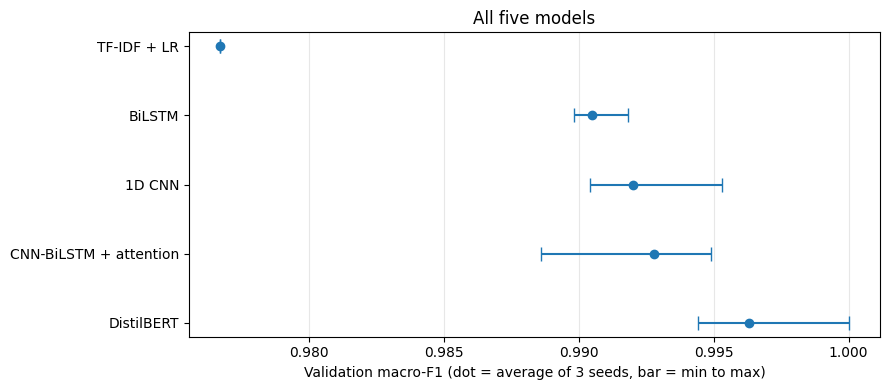

In [ ]:
# Average macro-F1 per model, with the min-max range over the 3 seeds
ranges = {"TF-IDF + LR": (final_table.loc["TF-IDF + LR", "macro_f1"],) * 2}
for m, df_, name in [("BiLSTM", rnn_results_df, best_rnn_name), ("1D CNN", cnn_results_df, best_cnn_name),
                     ("CNN-BiLSTM + attention", m4_results_df, best_m4_name), ("DistilBERT", m5_results_df, best_m5_name)]:
    row = df_.loc[df_["experiment"] == name].iloc[0]
    ranges[m] = (row["macro_f1_min"], row["macro_f1_max"])

means = final_table["macro_f1"].astype(float).to_numpy()
lows = means - np.array([ranges[m][0] for m in MODEL_ORDER])
highs = np.array([ranges[m][1] for m in MODEL_ORDER]) - means

plt.figure(figsize=(9, 4))
plt.errorbar(means, range(5), xerr=[lows, highs], fmt="o", capsize=5)
plt.yticks(range(5), MODEL_ORDER)
plt.gca().invert_yaxis()
plt.xlabel("Validation macro-F1 (dot = average of 3 seeds, bar = min to max)")
plt.title("All five models")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("results/macro_f1_all_models.png", dpi=150)
plt.show()

### 13.2 Are the differences real? Bootstrap intervals and McNemar's test

**Bootstrap:** we draw 3,974 validation tweets *with replacement* 2,000 times and recompute macro-F1 each time. The middle 95% of those scores is the interval. If two models' intervals overlap a lot, this validation set cannot tell them apart.

**McNemar's test** ([Dietterich, 1998](https://doi.org/10.1162/089976698300017197)) only looks at tweets where one model is right and the other is wrong. If both models were equally good, these would split roughly 50/50. A p-value below 0.05 means one model makes significantly fewer mistakes.

In [ ]:
rng = np.random.default_rng(0)
boot_samples = [rng.integers(0, len(y_val_ids), len(y_val_ids)) for _ in range(2000)]

ci_rows = []
for m in MODEL_ORDER:
    p = final_models[m]["pred_ids"]
    scores = [f1_score(y_val_ids[s], p[s], labels=range(5), average="macro", zero_division=0) for s in boot_samples]
    ci_rows.append({"model": m,
                    "macro_F1 (seed 42)": round(f1_score(y_val_ids, p, labels=range(5), average="macro"), 4),
                    "95% CI low": round(np.percentile(scores, 2.5), 4),
                    "95% CI high": round(np.percentile(scores, 97.5), 4)})
ci_df = pd.DataFrame(ci_rows)
display(ci_df)
ci_df.to_csv("results/bootstrap_ci.csv", index=False)

mcnemar_rows = []
for i, a in enumerate(MODEL_ORDER):
    for b in MODEL_ORDER[i + 1:]:
        a_right = final_models[a]["pred_ids"] == y_val_ids
        b_right = final_models[b]["pred_ids"] == y_val_ids
        only_a, only_b = int((a_right & ~b_right).sum()), int((~a_right & b_right).sum())
        p_value = binomtest(only_a, only_a + only_b, 0.5).pvalue if only_a + only_b else 1.0
        mcnemar_rows.append({"model A": a, "model B": b, "only A right": only_a, "only B right": only_b,
                             "p-value": round(p_value, 4), "significant (p<0.05)": p_value < 0.05})
mcnemar_df = pd.DataFrame(mcnemar_rows)
display(mcnemar_df)
mcnemar_df.to_csv("results/mcnemar_tests.csv", index=False)

,model,macro_F1 (seed 42),95% CI low,95% CI high
0,TF-IDF + LR,0.9767,0.9579,0.9905
1,BiLSTM,0.9899,0.9732,1.0000
2,1D CNN,0.9904,0.9749,1.0000
3,CNN-BiLSTM + attention,0.9949,0.9837,1.0000
4,DistilBERT,0.9944,0.9813,1.0000


,model A,model B,only A right,only B right,p-value,significant (p<0.05)
0,TF-IDF + LR,BiLSTM,2,19,0.0002,True
1,TF-IDF + LR,1D CNN,2,19,0.0002,True
2,TF-IDF + LR,CNN-BiLSTM + attention,3,19,0.0009,True
3,TF-IDF + LR,DistilBERT,2,19,0.0002,True
4,BiLSTM,1D CNN,1,1,1.0000,False
5,BiLSTM,CNN-BiLSTM + attention,3,2,1.0000,False
6,BiLSTM,DistilBERT,2,2,1.0000,False
7,1D CNN,CNN-BiLSTM + attention,2,1,1.0000,False
8,1D CNN,DistilBERT,2,2,1.0000,False
9,CNN-BiLSTM + attention,DistilBERT,2,3,1.0000,False


### 13.3 Confusion matrices, ROC and precision-recall curves

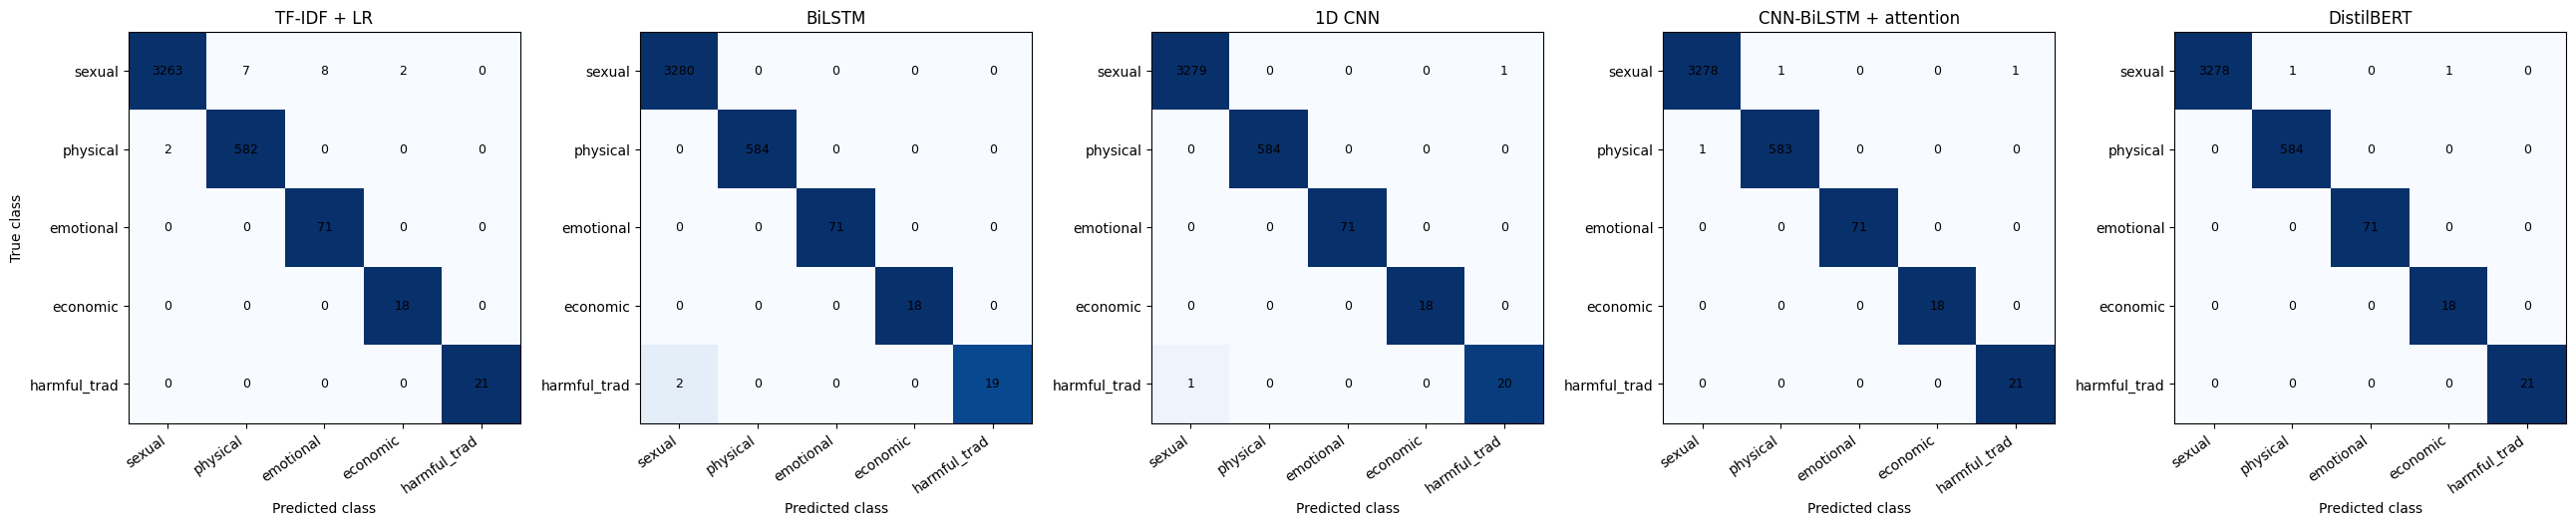

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
for ax, m in zip(axes, MODEL_ORDER):
    cm_m = confusion_matrix(y_val_ids, final_models[m]["pred_ids"], labels=range(5))
    ax.imshow(cm_m / cm_m.sum(axis=1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm_m[i, j], ha="center", va="center", fontsize=9)
    ax.set_xticks(range(5)); ax.set_xticklabels(short_names, rotation=35, ha="right")
    ax.set_yticks(range(5)); ax.set_yticklabels(short_names)
    ax.set_title(m); ax.set_xlabel("Predicted class")
axes[0].set_ylabel("True class")
plt.tight_layout()
plt.savefig("results/confusion_matrices_all_models.png", dpi=150)
plt.show()

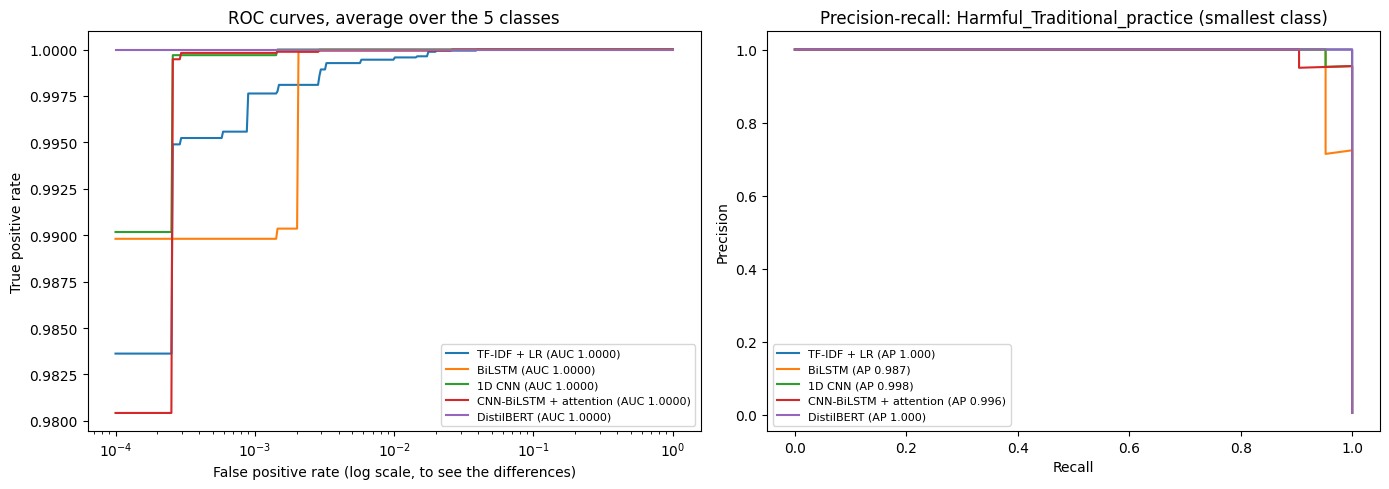

,macro ROC-AUC,macro PR-AUC,PR-AUC sexual,PR-AUC physical,PR-AUC emotional,PR-AUC economic,PR-AUC harmful_trad
model,,,,,,,
TF-IDF + LR,1.0,0.9998,1.0,0.9999,0.9992,1.0,1.0000
BiLSTM,1.0,0.9974,1.0,1.0000,1.0000,1.0,0.9869
1D CNN,1.0,0.9996,1.0,1.0000,1.0000,1.0,0.9978
CNN-BiLSTM + attention,1.0,0.9991,1.0,1.0000,1.0000,1.0,0.9956
DistilBERT,1.0,1.0000,1.0,1.0000,1.0000,1.0,1.0000


In [ ]:
Y_val_onehot = label_binarize(y_val_ids, classes=range(5))
auc_rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr_grid = np.logspace(-4, 0, 400)

for m in MODEL_ORDER:
    probs = final_models[m]["probs"]
    row = {"model": m}
    tprs = []
    for j, short in enumerate(short_names):
        fpr, tpr, _ = roc_curve(Y_val_onehot[:, j], probs[:, j])
        row[f"ROC-AUC {short}"] = round(auc(fpr, tpr), 4)
        row[f"PR-AUC {short}"] = round(average_precision_score(Y_val_onehot[:, j], probs[:, j]), 4)
        tprs.append(np.interp(fpr_grid, fpr, tpr))
    row["macro ROC-AUC"] = round(np.mean([row[f"ROC-AUC {s}"] for s in short_names]), 4)
    row["macro PR-AUC"] = round(np.mean([row[f"PR-AUC {s}"] for s in short_names]), 4)
    auc_rows.append(row)
    axes[0].plot(fpr_grid, np.mean(tprs, axis=0), label=f"{m} (AUC {row['macro ROC-AUC']:.4f})")

    precision, recall, _ = precision_recall_curve(Y_val_onehot[:, 4], probs[:, 4])
    axes[1].plot(recall, precision, label=f"{m} (AP {row['PR-AUC harmful_trad']:.3f})")

axes[0].set_xscale("log")
axes[0].set_xlabel("False positive rate (log scale, to see the differences)")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves, average over the 5 classes")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall: Harmful_Traditional_practice (smallest class)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("results/roc_pr_curves.png", dpi=150)
plt.show()

auc_df = pd.DataFrame(auc_rows).set_index("model")
display(auc_df[["macro ROC-AUC", "macro PR-AUC"] + [f"PR-AUC {s}" for s in short_names]])
auc_df.to_csv("results/roc_pr_auc.csv")

### 13.4 What the comparison shows

*(Fill in after running.)*

- **Ranking by average macro-F1:** ...
- **Do the seed ranges and bootstrap intervals overlap? Any McNemar p-value below 0.05?** If not, the honest conclusion is that the models are statistically tied on this validation set, and the differences come from a handful of tweets.
- **Most stable model (smallest std):** ...
- **Where the remaining errors are (confusion matrices):** ...
- **PR-AUC on the small classes:** does any model rank them clearly better? ...
- **Cost vs gain:** TF-IDF trains in seconds on a CPU; DistilBERT has ~66M parameters and needs a GPU. Is the gain worth it on this data? ...

## 14. Error analysis

All five models score above 0.97 macro-F1, so each makes only a few mistakes (from 2 to 19 tweets). Looking at each model alone would give too few examples, so we:

1. **Pool the mistakes of all five models** (seed-42 runs) and ask which tweets are hard for everyone and which only for some models.
2. **Look at which classes get confused** and read those tweets.
3. **Explain individual mistakes**, with TF-IDF word weights and Model 4's attention weights.
4. **Test keyword reliance directly**, on the validation set and on hand-written challenge tweets, because validation contains very few hard cases.
5. **Check for label noise**, since some "errors" may be wrong labels.

### 14.1 Pooled mistakes: hard for every model, or only for some?

In [ ]:
pred_names = {m: np.array([CLASS_NAMES[i] for i in final_models[m]["pred_ids"]]) for m in MODEL_ORDER}
wrong = {m: pred_names[m] != y_val.to_numpy() for m in MODEL_ORDER}
n_models_wrong = np.sum([wrong[m] for m in MODEL_ORDER], axis=0)

error_idx = np.where(n_models_wrong > 0)[0]
errors_df = pd.DataFrame({
    "Tweet_ID": validation_model["Tweet_ID"].to_numpy()[error_idx],
    "tweet": X_val_text.to_numpy()[error_idx],
    "true_label": y_val.to_numpy()[error_idx],
    "n_models_wrong": n_models_wrong[error_idx],
    "models_wrong": [", ".join(m for m in MODEL_ORDER if wrong[m][i]) for i in error_idx],
})
for m in MODEL_ORDER:
    errors_df[f"pred: {m}"] = pred_names[m][error_idx]
errors_df = errors_df.sort_values("n_models_wrong", ascending=False).reset_index(drop=True)
errors_df.to_csv("results/pooled_errors.csv", index=False)

print(f"Validation tweets wrong for at least one model: {len(errors_df)} of {len(y_val)}")
print("\nNumber of models that got each of these tweets wrong:")
print(errors_df["n_models_wrong"].value_counts().sort_index().rename("tweets").to_string())
print("\nTrue class of these tweets:")
print(errors_df["true_label"].value_counts().to_string())

Validation tweets wrong for at least one model: 26 of 3974

Number of models that got each of these tweets wrong:
n_models_wrong
1    24
2     2

True class of these tweets:
true_label
sexual_violence                 21
Physical_violence                3
Harmful_Traditional_practice     2


In [ ]:
print("Tweets that at least 3 of the 5 models got wrong (the genuinely hard cases):")
display(errors_df[errors_df["n_models_wrong"] >= 3][["tweet", "true_label", "n_models_wrong"] +
                                                    [f"pred: {m}" for m in MODEL_ORDER]])

only_tfidf = errors_df[errors_df["models_wrong"] == "TF-IDF + LR"]
print(f"\nWrong ONLY for TF-IDF + LR ({len(only_tfidf)} tweets): cases where word order or learned embeddings helped")
display(only_tfidf[["tweet", "true_label", "pred: TF-IDF + LR"]])

not_tfidf = errors_df[~errors_df["models_wrong"].str.contains("TF-IDF")]
print(f"\nWrong for a neural model but RIGHT for TF-IDF + LR ({len(not_tfidf)} tweets):")
display(not_tfidf[["tweet", "true_label", "models_wrong"]])

Tweets that at least 3 of the 5 models got wrong (the genuinely hard cases):


,tweet,true_label,n_models_wrong,pred: TF-IDF + LR,pred: BiLSTM,pred: 1D CNN,pred: CNN-BiLSTM + attention,pred: DistilBERT



Wrong ONLY for TF-IDF + LR (19 tweets): cases where word order or learned embeddings helped


,tweet,true_label,pred: TF-IDF + LR
2,Brent will get sexually raped in public...real...,sexual_violence,emotional_violence
3,"""The Testimony"" Krystle: My husband is not a v...",sexual_violence,Physical_violence
5,It is an outrageous lie to claim Tara has told...,sexual_violence,economic_violence
6,After reporting an officer for misconduct I wa...,sexual_violence,emotional_violence
7,I had one where Kenny beats did a live stream ...,Physical_violence,sexual_violence
9,JESUS CHRIST BETRAYED ME ALONG WITH MY HUSBAND...,sexual_violence,Physical_violence
11,When my husband came to know I have been disho...,sexual_violence,Physical_violence
12,"TW // rape , transphobia james made me read an...",sexual_violence,emotional_violence
13,I know it's been proven that Zack raped him bu...,sexual_violence,emotional_violence
14,"What a load of crap. I am a male, but I was 20...",sexual_violence,Physical_violence



Wrong for a neural model but RIGHT for TF-IDF + LR (7 tweets):


,tweet,true_label,models_wrong
0,This world is very different from what it was ...,Harmful_Traditional_practice,"BiLSTM, 1D CNN"
1,"My mother gave me over 2 marriage, Prince love...",sexual_violence,"1D CNN, CNN-BiLSTM + attention"
4,"""I was raped."" Sorry, that's a pre-existing co...",Physical_violence,CNN-BiLSTM + attention
8,I married my beloved husband five years after ...,sexual_violence,CNN-BiLSTM + attention
10,He beg me.,sexual_violence,DistilBERT
16,"The sexual violence was bad enough, but my rap...",sexual_violence,DistilBERT
24,"Just watched and I have to say, I’m ashamed I ...",Harmful_Traditional_practice,BiLSTM


### 14.2 Which classes get confused?

In [ ]:
pairs = []
for m in MODEL_ORDER:
    for t, p in zip(y_val.to_numpy()[wrong[m]], pred_names[m][wrong[m]]):
        pairs.append({"model": m, "true -> predicted": f"{t} -> {p}"})
pairs_df = pd.DataFrame(pairs)
if len(pairs_df):
    confusion_pairs = pd.crosstab(pairs_df["true -> predicted"], pairs_df["model"]).reindex(columns=MODEL_ORDER, fill_value=0)
    confusion_pairs["total"] = confusion_pairs.sum(axis=1)
    display(confusion_pairs.sort_values("total", ascending=False))
    confusion_pairs.to_csv("results/confusion_pairs.csv")

model,TF-IDF + LR,BiLSTM,1D CNN,CNN-BiLSTM + attention,DistilBERT,total
true -> predicted,,,,,,
sexual_violence -> Physical_violence,7,0,0,1,1,9
sexual_violence -> emotional_violence,8,0,0,0,0,8
Physical_violence -> sexual_violence,2,0,0,1,0,3
Harmful_Traditional_practice -> sexual_violence,0,2,1,0,0,3
sexual_violence -> economic_violence,2,0,0,0,1,3
sexual_violence -> Harmful_Traditional_practice,0,0,1,1,0,2


### 14.3 Why did TF-IDF get it wrong? Word contributions

For TF-IDF + Logistic Regression we can see exactly which words pushed a tweet towards the wrong class: contribution = the word's TF-IDF value × its weight for that class. If one keyword from another class dominates, the mistake is a keyword mistake.

In [ ]:
tfidf_words = best_tfidf.get_feature_names_out()

def explain_tfidf(text, top=6):
    x = best_tfidf.transform([text])
    pred_row = best_model.predict_proba(x)[0].argmax()            # row in best_model.classes_ (alphabetical)
    cols = x.nonzero()[1]
    contributions = x.toarray()[0, cols] * best_model.coef_[pred_row, cols]
    top_k = np.argsort(contributions)[::-1][:top]
    return best_model.classes_[pred_row], ", ".join(f"{tfidf_words[cols[k]]} ({contributions[k]:+.2f})" for k in top_k)

tfidf_wrong = errors_df[errors_df["pred: TF-IDF + LR"] != errors_df["true_label"]]
explained = [explain_tfidf(t) for t in tfidf_wrong["tweet"]]
display(pd.DataFrame({"tweet": tfidf_wrong["tweet"].values,
                      "true": tfidf_wrong["true_label"].values,
                      "TF-IDF predicted": [e[0] for e in explained],
                      "words pushing towards that prediction": [e[1] for e in explained]}))

,tweet,true,TF-IDF predicted,words pushing towards that prediction
0,Brent will get sexually raped in public...real...,sexual_violence,emotional_violence,"public (+1.72), in public (+1.04), in (+0.23),..."
1,"""The Testimony"" Krystle: My husband is not a v...",sexual_violence,Physical_violence,"husband (+1.46), my husband (+1.03), my (+0.42..."
2,It is an outrageous lie to claim Tara has told...,sexual_violence,economic_violence,"fired (+1.40), job (+0.97), because (+0.59), f..."
3,After reporting an officer for misconduct I wa...,sexual_violence,emotional_violence,"public (+1.74), in public (+1.06), in (+0.23),..."
4,I had one where Kenny beats did a live stream ...,Physical_violence,sexual_violence,"he (+0.25), did (+0.07), me for (+0.05), me (+..."
5,JESUS CHRIST BETRAYED ME ALONG WITH MY HUSBAND...,sexual_violence,Physical_violence,"husband (+1.44), my husband (+1.02), my (+0.58..."
6,When my husband came to know I have been disho...,sexual_violence,Physical_violence,"husband (+1.23), my husband (+0.87), my (+0.35..."
7,"TW // rape , transphobia james made me read an...",sexual_violence,emotional_violence,"public (+1.55), in public (+0.94), in (+0.21),..."
8,I know it's been proven that Zack raped him bu...,sexual_violence,emotional_violence,"public (+1.40), in public (+0.85), in (+0.32),..."
9,"What a load of crap. I am a male, but I was 20...",sexual_violence,Physical_violence,"husband (+1.33), my husband (+0.93), my (+0.38..."


### 14.4 Where does Model 4 look? Attention weights

For each tweet we list the 5 words with the highest attention weight (from Model 4, Experiment 1). First for the tweets Model 4 got wrong, then, for comparison, for correct tweets from each class.

In [ ]:
def top_attention_words(texts, k=5):
    seqs = vectorizer(np.array(texts, dtype=object).astype(str)).numpy()
    weights = m4_attention_model.predict(seqs, verbose=0)
    out = []
    for seq, w in zip(seqs, weights):
        n_words = int((seq != 0).sum())
        top = np.argsort(w[:n_words])[::-1][:k]
        out.append(", ".join(f"{vocab[seq[j]]} ({w[j]:.2f})" for j in top))
    return out

m4_exp1_pred = np.array([CLASS_NAMES[i] for i in m4_attention_clf.predict(X_val_seq, verbose=0).argmax(1)])
m4_wrong_idx = np.where(m4_exp1_pred != y_val.to_numpy())[0]
print(f"Model 4 (Exp 1, seed 42) mistakes: {len(m4_wrong_idx)}")
if len(m4_wrong_idx):
    display(pd.DataFrame({"tweet": X_val_text.to_numpy()[m4_wrong_idx],
                          "true": y_val.to_numpy()[m4_wrong_idx],
                          "predicted": m4_exp1_pred[m4_wrong_idx],
                          "top attention words": top_attention_words(X_val_text.to_numpy()[m4_wrong_idx])}))

examples = pd.concat([validation_model[validation_model["type"] == c].head(2) for c in CLASS_NAMES])
display(pd.DataFrame({"tweet": examples["tweet_clean"].values, "true": examples["type"].values,
                      "top attention words": top_attention_words(examples["tweet_clean"].values)}))

Model 4 (Exp 1, seed 42) mistakes: 1


,tweet,true,predicted,top attention words
0,This world is very different from what it was ...,Harmful_Traditional_practice,sexual_violence,"benefiting (0.20), protecting (0.10), [UNK] (0..."


,tweet,true,top attention words
0,Lol. Both guys who raped me walk completely fr...,sexual_violence,"me (0.38), raped (0.37), who (0.25), completel..."
1,Nick saban protected my Rapeist years ago when...,sexual_violence,"me (0.41), raped (0.37), who (0.16), rape (0.0..."
2,"theyre like, i just wanna be a baby maker with...",Physical_violence,"me (0.40), beats (0.36), who (0.20), husband (..."
3,hi kyle you are my favourite on you have it al...,Physical_violence,"me (0.34), beats (0.33), it (0.28), girls (0.0..."
4,Is that coked up asshole Steve Corn still work...,emotional_violence,"in (0.31), public (0.29), me (0.17), high (0.1..."
5,"He cheated, humiliated me in public intentiona...",emotional_violence,"in (0.23), public (0.22), me (0.19), humiliate..."
6,Just a big old woman sitting at your door... T...,economic_violence,"be (0.41), fired (0.29), tho (0.10), that (0.0..."
7,You have not bothered to check the facts on th...,economic_violence,"from (0.47), fired (0.27), a (0.12), was (0.06..."
8,I thought that US was a civilized country but ...,Harmful_Traditional_practice,"who (0.24), mothers (0.16), by (0.15), do (0.1..."
9,This world is very different from what it was ...,Harmful_Traditional_practice,"benefiting (0.20), protecting (0.10), [UNK] (0..."


In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Step 1: share of each class that contains its main keyword
main_keyword = {"sexual_violence": r"raped", "Physical_violence": r"beats",
                "emotional_violence": r"humiliated|insulted", "economic_violence": r"fired",
                "Harmful_Traditional_practice": r"forced|fgm|marriage"}
step1 = []
for c in CLASS_NAMES:
    texts = X_val_text[y_val == c].str.lower()
    pattern = r"\b(" + main_keyword[c] + r")\b"
    step1.append({"class": c, "main keyword": main_keyword[c].replace("|", " / "), "tweets": len(texts),
                  "share containing it": f"{texts.str.contains(pattern).mean():.1%}"})
print("Step 1: how many validation tweets contain their class's main keyword")
display(pd.DataFrame(step1))

# Automatic keyword list (8 strongest single words per class in the TF-IDF model), shown for comparison
ignore = set(ENGLISH_STOP_WORDS) | {"user", "url"}   # "user"/"url" come from the <USER>/<URL> placeholders
single_words = [i for i, w in enumerate(tfidf_words) if " " not in w and w not in ignore and not w.isdigit()]
auto_keywords = {}
for row, class_name in enumerate(best_model.classes_):
    top = np.argsort(best_model.coef_[row, single_words])[::-1][:8]
    auto_keywords[class_name] = [tfidf_words[single_words[k]] for k in top]
print("Automatic keyword list from TF-IDF weights (note the non-violence topic words):")
display(pd.DataFrame(auto_keywords)[CLASS_NAMES])

# Step 2: hand-checked keyword list used for the groups
keywords = {
    "sexual_violence": ["raped", "rape", "rapist", "raping", "rapes", "molested", "sexually", "defiled"],
    "Physical_violence": ["beats", "beat", "beating", "beaten", "hit", "hits", "slapped", "punched", "kicked"],
    "emotional_violence": ["humiliated", "humiliate", "insulted", "insult", "insults", "verbally"],
    "economic_violence": ["fired", "job", "jobs", "salary", "wages", "boss"],
    "Harmful_Traditional_practice": ["forced", "marriage", "married", "fgm", "mutilation", "genital", "circumcision"],
}

val_tokens = [set(re.findall(r"\b\w+\b", t.lower())) for t in X_val_text]
keyword_group = []
for tokens, c in zip(val_tokens, y_val):
    own = bool(tokens & set(keywords[c]))
    other = any(tokens & set(keywords[o]) for o in CLASS_NAMES if o != c)
    keyword_group.append({(True, False): "(a) own keyword only", (True, True): "(b) own + other keyword",
                          (False, True): "(c) other keyword only", (False, False): "(d) no keyword"}[(own, other)])
keyword_group = np.array(keyword_group)

rows = []
for g in sorted(set(keyword_group)):
    mask = keyword_group == g
    row = {"group": g, "tweets": int(mask.sum()), "share": f"{mask.mean():.1%}"}
    for m in MODEL_ORDER:
        row[m] = round(1 - wrong[m][mask].mean(), 4)
    rows.append(row)
keyword_df = pd.DataFrame(rows)
print("Step 2: accuracy per group (seed-42 run of each model):")
display(keyword_df)
print("Group sizes per class:")
display(pd.crosstab(y_val.to_numpy(), keyword_group))

print("Tweets with no keyword at all (read them: several look off-topic or mislabelled):")
display(pd.DataFrame({"tweet": X_val_text.to_numpy()[keyword_group == "(d) no keyword"],
                      "label": y_val.to_numpy()[keyword_group == "(d) no keyword"]}))
keyword_df.to_csv("results/keyword_reliance.csv", index=False)

Step 1: how many validation tweets contain their class's main keyword


/tmp/ipykernel_2921/1926448634.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "share containing it": f"{texts.str.contains(pattern).mean():.1%}"})


,class,main keyword,tweets,share containing it
0,sexual_violence,raped,3280,98.6%
1,Physical_violence,beats,584,98.5%
2,emotional_violence,humiliated / insulted,71,95.8%
3,economic_violence,fired,18,100.0%
4,Harmful_Traditional_practice,forced / fgm / marriage,21,76.2%


Automatic keyword list from TF-IDF weights (note the non-violence topic words):


,sexual_violence,Physical_violence,emotional_violence,economic_violence,Harmful_Traditional_practice
0,raped,beats,public,fired,forced
1,rape,husband,humiliated,job,marriage
2,rapist,wife,insulted,woman,fgm
3,girl,love,verbally,boss,undergo
4,sex,heart,abused,jobs,mutilation
5,said,tells,transport,manager,genital
6,drunk,court,president,refused,child
7,killed,beat,private,got,female


...

,group,tweets,share,TF-IDF + LR,BiLSTM,1D CNN,CNN-BiLSTM + attention,DistilBERT
0,(a) own keyword only,3600,90.6%,0.9964,0.9997,1.0000,1.0000,1.0000
1,(b) own + other keyword,348,8.8%,0.9856,0.9971,0.9943,0.9914,0.9971
2,(c) other keyword only,14,0.4%,1.0000,1.0000,1.0000,1.0000,1.0000
3,(d) no keyword,12,0.3%,0.9167,1.0000,1.0000,1.0000,0.9167


Group sizes per class:


col_0,(a) own keyword only,(b) own + other keyword,(c) other keyword only,(d) no keyword
row_0,,,,
Harmful_Traditional_practice,15,6,0,0
Physical_violence,532,44,1,7
economic_violence,17,1,0,0
emotional_violence,65,6,0,0
sexual_violence,2971,291,13,5


Tweets with no keyword at all (read them: several look off-topic or mislabelled):


,tweet,label
0,A huge turn-off in 2021 Girls: “Why he’s Chill...,sexual_violence
1,Biafrans: the utterance of made me understand ...,sexual_violence
2,I listened to a podcast today during my kids b...,Physical_violence
3,Love Gamechops. My husband sent me this link t...,Physical_violence
4,When court record tampering rampage was going ...,sexual_violence
5,He beg me.,sexual_violence
6,"Haaaaa that's my husband Mos, he went to the t...",Physical_violence
7,"I just seen a post on fb that said "" the sims ...",Physical_violence
8,pet peave being followed around when im in a h...,Physical_violence
9,I'm a housewife. And trust me. My husband did ...,Physical_violence


### 14.6 Challenge tweets: paraphrases, misleading keywords and misspellings



In [ ]:
challenge = pd.DataFrame([
    ("paraphrase", "He forced himself on me after the party even though I kept saying no", "sexual_violence"),
    ("paraphrase", "My husband slapped me and pushed me down the stairs", "Physical_violence"),
    ("paraphrase", "He punched me in the face because dinner was late", "Physical_violence"),
    ("paraphrase", "He calls me worthless and stupid every single day", "emotional_violence"),
    ("paraphrase", "My partner mocks me in front of his friends until I cry", "emotional_violence"),
    ("paraphrase", "He takes my whole salary and gives me nothing for food", "economic_violence"),
    ("paraphrase", "My husband will not let me work or open a bank account", "economic_violence"),
    ("paraphrase", "They are marrying off my 14 year old sister to a man of 50", "Harmful_Traditional_practice"),
    ("paraphrase", "Her family insists she must be cut before her wedding", "Harmful_Traditional_practice"),
    ("misleading keyword", "He beats me at chess every time, but I was fired from my job because I am a woman", "economic_violence"),
    ("misleading keyword", "He never beat me, but he insulted and humiliated me in public every day", "emotional_violence"),
    ("misleading keyword", "I was forced to resign after I told my boss I was pregnant", "economic_violence"),
    ("misleading keyword", "No one raped her, but her husband took all her money and stopped her from working", "economic_violence"),
    ("misleading keyword", "My boss humiliated me then fired me for refusing to sleep with him", "sexual_violence"),
    ("spelling", "he r@ped me and nobody believed me", "sexual_violence"),
    ("spelling", "my hubby beatz me evry nyt", "Physical_violence"),
    ("spelling", "got fyred coz am a gurl", "economic_violence"),
    ("spelling", "they want 2 do fgm on my lil cousin", "Harmful_Traditional_practice"),
    ("spelling", "he humilated me infront of evryone", "emotional_violence"),
    ("mixed", "He insulted me and then hit me with a belt", "Physical_violence"),
    ("mixed", "He beat me and took my wages so I could not leave", "Physical_violence"),
    ("mixed", "My father forced me into marriage and beat me when I refused", "Harmful_Traditional_practice"),
    ("mixed", "He raped me and then told everyone I was worthless", "sexual_violence"),
], columns=["type_of_test", "tweet", "expected"])

for m in MODEL_ORDER:
    challenge[m] = [CLASS_NAMES[i] for i in final_models[m]["predict"](challenge["tweet"].tolist()).argmax(axis=1)]

display(challenge)
challenge.to_csv("results/challenge_tweets_predictions.csv", index=False)

challenge_acc = pd.DataFrame({m: (challenge[m] == challenge["expected"]).groupby(challenge["type_of_test"]).mean()
                              for m in MODEL_ORDER})
challenge_acc.loc["all 23"] = [(challenge[m] == challenge["expected"]).mean() for m in MODEL_ORDER]
print("Share correct per type of test:")
display(challenge_acc.round(2))
challenge_acc.to_csv("results/challenge_tweets_accuracy.csv")

,type_of_test,tweet,expected,TF-IDF + LR,BiLSTM,1D CNN,CNN-BiLSTM + attention,DistilBERT
0,paraphrase,He forced himself on me after the party even t...,sexual_violence,sexual_violence,sexual_violence,sexual_violence,sexual_violence,sexual_violence
1,paraphrase,My husband slapped me and pushed me down the s...,Physical_violence,Physical_violence,Physical_violence,Physical_violence,Physical_violence,Physical_violence
2,paraphrase,He punched me in the face because dinner was late,Physical_violence,sexual_violence,Harmful_Traditional_practice,sexual_violence,Harmful_Traditional_practice,sexual_violence
3,paraphrase,He calls me worthless and stupid every single day,emotional_violence,sexual_violence,emotional_violence,sexual_violence,sexual_violence,sexual_violence
4,paraphrase,My partner mocks me in front of his friends un...,emotional_violence,sexual_violence,sexual_violence,emotional_violence,emotional_violence,Physical_violence
5,paraphrase,He takes my whole salary and gives me nothing ...,economic_violence,sexual_violence,Physical_violence,sexual_violence,sexual_violence,economic_violence
6,paraphrase,My husband will not let me work or open a bank...,economic_violence,Physical_violence,Physical_violence,Physical_violence,Physical_violence,Physical_violence
7,paraphrase,They are marrying off my 14 year old sister to...,Harmful_Traditional_practice,sexual_violence,sexual_violence,sexual_violence,sexual_violence,Physical_violence
8,paraphrase,Her family insists she must be cut before her ...,Harmful_Traditional_practice,sexual_violence,sexual_violence,sexual_violence,sexual_violence,Harmful_Traditional_practice
9,misleading keyword,"He beats me at chess every time, but I was fir...",economic_violence,economic_violence,Physical_violence,economic_violence,Physical_violence,economic_violence


Share correct per type of test:


,TF-IDF + LR,BiLSTM,1D CNN,CNN-BiLSTM + attention,DistilBERT
type_of_test,,,,,
misleading keyword,0.40,0.20,0.40,0.20,0.60
mixed,0.50,0.50,0.50,0.50,0.50
paraphrase,0.22,0.33,0.33,0.33,0.44
spelling,0.40,0.60,0.80,0.80,0.60
all 23,0.35,0.39,0.48,0.43,0.52


In [ ]:
# Do the models even "see" the misspelled words?
vocab_set = set(vocab)
for t in challenge.loc[challenge["type_of_test"] == "spelling", "tweet"]:
    unknown = [w for w in re.findall(r"\b\w+\b", t.lower()) if w not in vocab_set]
    print(f"{t}\n   unknown to Models 2-4 (all become the same ID): {unknown}"
          f"\n   DistilBERT pieces: {tokenizer.tokenize(t)}\n")

he r@ped me and nobody believed me
   unknown to Models 2-4 (all become the same ID): ['ped']
   DistilBERT pieces: ['he', 'r', '@', 'pe', '##d', 'me', 'and', 'nobody', 'believed', 'me']

my hubby beatz me evry nyt
   unknown to Models 2-4 (all become the same ID): ['beatz', 'evry']
   DistilBERT pieces: ['my', 'hub', '##by', 'beat', '##z', 'me', 'ev', '##ry', 'ny', '##t']

got fyred coz am a gurl
   unknown to Models 2-4 (all become the same ID): ['fyred']
   DistilBERT pieces: ['got', 'f', '##yre', '##d', 'co', '##z', 'am', 'a', 'gu', '##rl']

they want 2 do fgm on my lil cousin
   unknown to Models 2-4 (all become the same ID): []
   DistilBERT pieces: ['they', 'want', '2', 'do', 'f', '##gm', 'on', 'my', 'lil', 'cousin']

he humilated me infront of evryone
   unknown to Models 2-4 (all become the same ID): ['humilated', 'evryone']
   DistilBERT pieces: ['he', 'hum', '##ila', '##ted', 'me', 'in', '##front', 'of', 'ev', '##ry', '##one']



### 14.7 Label noise



In [ ]:
conflicting = train_model.groupby("tweet_clean")["type"].nunique()
conflicting = conflicting[conflicting > 1].index
print(f"Training tweets with the same text but different labels: {len(conflicting)} groups")
display(train_model[train_model["tweet_clean"].isin(conflicting)][["tweet_clean", "type"]].sort_values("tweet_clean"))

all_agree = errors_df[(errors_df["n_models_wrong"] == 5) &
                      (errors_df[[f"pred: {m}" for m in MODEL_ORDER]].nunique(axis=1) == 1)]
print(f"\nValidation tweets where all 5 models agree on another label: {len(all_agree)}")
display(all_agree[["tweet", "true_label", f"pred: {MODEL_ORDER[0]}"]].rename(columns={f"pred: {MODEL_ORDER[0]}": "all models predict"}))

Training tweets with the same text but different labels: 2 groups


,tweet_clean,type
11825,account is temporarily unavailable because it ...,sexual_violence
30504,account is temporarily unavailable because it ...,Physical_violence
2770,"and he forced me hug to him, and later he piss...",emotional_violence
30726,"and he forced me hug to him, and later he piss...",sexual_violence



Validation tweets where all 5 models agree on another label: 0


,tweet,true_label,all models predict


### 14.8 Mistakes by tweet length

In [ ]:
val_words = X_val_text.str.split().str.len().to_numpy()
length_bin = pd.cut(val_words, bins=[0, 15, 30, 45, 200], labels=["1-15", "16-30", "31-45", "46+"])
rows = []
for b in length_bin.categories:
    mask = np.asarray(length_bin == b)
    if mask.sum() == 0:
        continue
    row = {"words": b, "tweets": int(mask.sum())}
    for m in MODEL_ORDER:
        row[m] = int(wrong[m][mask].sum())
    rows.append(row)
print("Number of mistakes per tweet length (seed-42 runs):")
display(pd.DataFrame(rows))

Number of mistakes per tweet length (seed-42 runs):


,words,tweets,TF-IDF + LR,BiLSTM,1D CNN,CNN-BiLSTM + attention,DistilBERT
0,1-15,379,0,0,0,0,1
1,16-30,844,5,0,1,2,0
2,31-45,980,7,2,1,0,0
3,46+,1771,7,0,0,1,1


### 14.9 Does the test set look like the training data?



In [ ]:
X_test_text = test["tweet_clean"].astype(str)
test_dist = pd.DataFrame({"train (true labels)": y_train.value_counts(normalize=True).reindex(CLASS_NAMES)})
test_pred_ids = {}
for m in MODEL_ORDER:
    test_pred_ids[m] = final_models[m]["predict"](X_test_text.tolist()).argmax(axis=1)
    test_dist[f"test: {m}"] = pd.Series(test_pred_ids[m]).map(dict(enumerate(CLASS_NAMES))).value_counts(normalize=True).reindex(CLASS_NAMES)
display((test_dist.fillna(0) * 100).round(2))

print("Agreement with DistilBERT on the test set:")
for m in MODEL_ORDER[:-1]:
    print(f"  {m:25s} {(test_pred_ids[m] == test_pred_ids['DistilBERT']).mean():.4f}")

best_overall = final_table["macro_f1"].astype(float).idxmax()
submission = pd.DataFrame({"Tweet_ID": test["Tweet_ID"], "type": [CLASS_NAMES[i] for i in test_pred_ids[best_overall]]})
submission.to_csv("results/zindi_submission.csv", index=False)
print("\nZindi submission written with:", best_overall)

,train (true labels),test: TF-IDF + LR,test: BiLSTM,test: 1D CNN,test: CNN-BiLSTM + attention,test: DistilBERT
type,,,,,,
sexual_violence,82.32,76.37,72.88,73.36,73.12,72.09
Physical_violence,15.03,0.40,1.08,0.81,0.85,0.31
emotional_violence,1.63,4.13,4.22,4.53,4.55,4.17
economic_violence,0.56,1.17,3.13,2.55,2.48,3.18
Harmful_Traditional_practice,0.47,17.93,18.69,18.75,19.00,20.26


Agreement with DistilBERT on the test set:
  TF-IDF + LR               0.9409
  BiLSTM                    0.9496
  1D CNN                    0.9664
  CNN-BiLSTM + attention    0.9598

Zindi submission written with: DistilBERT
